# Seeded LC vs BCO on Mumford0

This notebook compares LC construction, seeded LC improvement, and BCO variants on `Mumford0` with the same route contract used by the NX-heuristic dataset:

- `N_ROUTES = 10`
- `MIN_ROUTE_LEN = 2`
- `MAX_ROUTE_LEN = 12`

The BCO variants use readable names for the mutation mix, while the low-level BCO API still receives its internal `n_type*` counters.


## 1. Imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader

from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config
from connectpt.routes_generator.improvement_learning import load_raw_graphs_and_lc_routes
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.bee_colony import bee_colony
from connectpt.routes_generator.torch_utils import dump_routes, get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
import connectpt.routes_generator.utils as lrnu


## 2. Paths And Experiment Parameters


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "connectpt").exists() and (candidate / "examples").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")

ROOT_DIR = find_repo_root()
CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
BENCHMARK_DIR = ROOT_DIR / "examples" / "data" / "benchmark"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "data" / "model_weights" / "inductive_random_graphs_weighted_connectivity.pt"
EDIT_MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "route_generator" / "lc_improvement_outputs" / "improvement_lc_improvement_trim.pt"
OUTPUT_ROUTES_DIR = ROOT_DIR / "examples" / "route_generator" / "output_routes"

CITY_NAME = "Mumford0"

N_ROUTES = 10
MIN_ROUTE_LEN = 2
MAX_ROUTE_LEN = 12

LC_SAMPLES = 100
USE_NEURAL_BCO = False
BCO_N_BEES = 10
BCO_N_ITERATIONS = 20
BCO_N_TYPE1_BEES = 5
BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN = False
BCO_EDIT_IGNORE_MAX_ROUTE_LEN = False
BCO_TRIM_IGNORE_MAX_ROUTE_LEN = False
BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN = False
BCO_WORSE_ACCEPT_TEMPERATURE = 0.0
BCO_WORSE_ACCEPT_DECAY = 0.995
BCO_WORSE_ACCEPT_MIN_TEMPERATURE = 0.001
BCO_WORSE_SELECTION_TEMPERATURE = 0.0
BCO_WORSE_SELECTION_DECAY = 0.995
BCO_WORSE_SELECTION_MIN_TEMPERATURE = 0.001
BCO_WORSE_SELECTION_UNIFORM_MIX = 0.05
BCO_WORSE_SELECTION_ELITE_COUNT = 1

DEMAND_TIME_WEIGHT = 0.33
ROUTE_TIME_WEIGHT = 0.33
MEDIAN_CONNECTIVITY_WEIGHT = 0.33

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"CFG_DIR: {CFG_DIR}")
print(f"MODEL_WEIGHTS_PATH exists: {MODEL_WEIGHTS_PATH.exists()}")
print(f"EDIT_MODEL_WEIGHTS_PATH exists: {EDIT_MODEL_WEIGHTS_PATH.exists()}")


ROOT_DIR: D:\PythonProjects\connectpt
CFG_DIR: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
MODEL_WEIGHTS_PATH exists: True
EDIT_MODEL_WEIGHTS_PATH exists: True


## 3. Load Benchmark Tensors


In [3]:
def load_benchmark_tensors(city_name: str = CITY_NAME) -> dict:
    node_locs = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Coords.txt", skip_header=1),
        dtype=torch.float32,
    )
    street_adj = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}TravelTimes.txt"),
        dtype=torch.float32,
    ) * 60
    demand = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Demand.txt"),
        dtype=torch.float32,
    )
    return {
        "node_locs": node_locs,
        "street_adj": street_adj,
        "demand": demand,
    }

input_tensors = load_benchmark_tensors()
print({key: tuple(value.shape) for key, value in input_tensors.items()})


{'node_locs': (30, 2), 'street_adj': (30, 30), 'demand': (30, 30)}


## 4. Helper Functions


In [4]:
def make_test_dataloader(dataset_cfg):
    dataset = get_dataset_from_config(dataset_cfg, tensors=input_tensors)
    return DataLoader(dataset, batch_size=1)


def make_tensor_dataloader(dataset_cfg, tensors):
    dataset = get_dataset_from_config(dataset_cfg, tensors=tensors)
    return DataLoader(dataset, batch_size=1)


BCO_ROUTE_SELECTION_MODES = {
    "uniform": {
        "label": "uniform random",
        "use_demand_weighted_route_selection": False,
    },
}

MUTATION_TYPES = (
    {"key": "type1", "slug": "heuristic_rebuild", "label": "heuristic rebuild"},
    {"key": "type2", "slug": "local_endpoint_edit", "label": "local endpoint edit"},
    {"key": "type3", "slug": "path_mix_rebuild", "label": "path mix rebuild"},
    {"key": "type4", "slug": "construction_extend", "label": "construction extend"},
    {"key": "type5", "slug": "extend_trim_edit", "label": "extend/trim edit"},
    {"key": "type6", "slug": "trim_only", "label": "trim only"},
    {"key": "type7", "slug": "trim_then_extend", "label": "trim then extend"},
)
MUTATION_TYPE_KEYS = tuple(item["key"] for item in MUTATION_TYPES)
MUTATION_TYPE_SLUGS = {item["key"]: item["slug"] for item in MUTATION_TYPES}
MUTATION_TYPE_LABELS = {item["key"]: item["label"] for item in MUTATION_TYPES}


def mutation_slug(type_name: str) -> str:
    return MUTATION_TYPE_SLUGS[type_name]


def mutation_label(type_name: str) -> str:
    return MUTATION_TYPE_LABELS[type_name]


def route_selection_mode_label(mode_key: str) -> str:
    return BCO_ROUTE_SELECTION_MODES[mode_key]["label"]


def route_selection_mode_suffix(mode_key: str) -> str:
    return mode_key


def build_lc_cfg(
    run_name: str,
    n_routes: int,
    min_route_len: int,
    max_route_len: int,
    demand_time_weight: float = DEMAND_TIME_WEIGHT,
    route_time_weight: float = ROUTE_TIME_WEIGHT,
    median_connectivity_weight: float = MEDIAN_CONNECTIVITY_WEIGHT,
):
    params = {
        "dataset_name": "tensor",
        "n_routes": n_routes,
        "min_route_len": min_route_len,
        "max_route_len": max_route_len,
        "demand_time_weight": demand_time_weight,
        "route_time_weight": route_time_weight,
        "median_connectivity_weight": median_connectivity_weight,
        "run_name": run_name,
        "model_weights": str(MODEL_WEIGHTS_PATH),
    }
    cfg = get_eval_cfg(str(CFG_DIR), "eval_model_mumford", params)
    cfg.batch_size = 1
    return cfg


def build_bco_cfg(
    run_name: str,
    n_routes: int,
    min_route_len: int,
    max_route_len: int,
    use_neural_bees: bool = USE_NEURAL_BCO,
    n_bees: int = BCO_N_BEES,
    n_type1_bees: int = BCO_N_TYPE1_BEES,
    n_type2_bees: int | None = None,
    n_type4_bees: int = 0,
    n_type5_bees: int = 0,
    n_type6_bees: int = 0,
    n_type7_bees: int = 0,
    ignore_type4_max_route_len: bool = BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
    ignore_type5_max_route_len: bool = BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
    ignore_type6_max_route_len: bool = BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
    ignore_type7_max_route_len: bool = BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
    use_demand_weighted_route_selection: bool = False,
    demand_time_weight: float = DEMAND_TIME_WEIGHT,
    route_time_weight: float = ROUTE_TIME_WEIGHT,
    median_connectivity_weight: float = MEDIAN_CONNECTIVITY_WEIGHT,
    worse_accept_temperature: float = BCO_WORSE_ACCEPT_TEMPERATURE,
    worse_accept_decay: float = BCO_WORSE_ACCEPT_DECAY,
    worse_accept_min_temperature: float = BCO_WORSE_ACCEPT_MIN_TEMPERATURE,
    worse_selection_temperature: float = BCO_WORSE_SELECTION_TEMPERATURE,
    worse_selection_decay: float = BCO_WORSE_SELECTION_DECAY,
    worse_selection_min_temperature: float = BCO_WORSE_SELECTION_MIN_TEMPERATURE,
    worse_selection_uniform_mix: float = BCO_WORSE_SELECTION_UNIFORM_MIX,
    worse_selection_elite_count: int = BCO_WORSE_SELECTION_ELITE_COUNT,
):
    """Build a BCO config.

    User-facing mutation names:
      heuristic_rebuild      - rebuild the chosen route
      local_endpoint_edit    - local extend/shorten by one stop
      path_mix_rebuild       - random path-combiner rebuild
      construction_extend    - one construction-model extension/halt step
      extend_trim_edit       - one edit-model extend/trim/halt step
      trim_only              - one edit-model trim/halt step
      trim_then_extend       - trim/halt, then construction extend/halt
    """
    base_cfg_name = "neural_bco_mumford" if use_neural_bees else "bco_mumford"
    effective_type2 = (
        n_bees - n_type1_bees - n_type4_bees - n_type5_bees - n_type6_bees - n_type7_bees
        if n_type2_bees is None
        else n_type2_bees
    )
    overrides = [
        "+eval=mumford0",
        "++eval.dataset.type=tensor",
        f"++eval.n_routes={n_routes}",
        f"++eval.min_route_len={min_route_len}",
        f"++eval.max_route_len={max_route_len}",
        f"++experiment.cost_function.kwargs.demand_time_weight={demand_time_weight}",
        f"++experiment.cost_function.kwargs.route_time_weight={route_time_weight}",
        f"++experiment.cost_function.kwargs.median_connectivity_weight={median_connectivity_weight}",
        f"++run_name={run_name}",
        f"++n_bees={n_bees}",
        f"++n_iterations={BCO_N_ITERATIONS}",
        f"++n_type1_bees={n_type1_bees}",
        f"++n_type2_bees={effective_type2}",
        f"++n_type4_bees={n_type4_bees}",
        f"++n_type5_bees={n_type5_bees}",
        f"++n_type6_bees={n_type6_bees}",
        f"++n_type7_bees={n_type7_bees}",
        f"++ignore_type4_max_route_len={str(ignore_type4_max_route_len).lower()}",
        f"++ignore_type5_max_route_len={str(ignore_type5_max_route_len).lower()}",
        f"++ignore_type6_max_route_len={str(ignore_type6_max_route_len).lower()}",
        f"++ignore_type7_max_route_len={str(ignore_type7_max_route_len).lower()}",
        f"++use_demand_weighted_route_selection={str(use_demand_weighted_route_selection).lower()}",
        f"++worse_accept_temperature={worse_accept_temperature}",
        f"++worse_accept_decay={worse_accept_decay}",
        f"++worse_accept_min_temperature={worse_accept_min_temperature}",
        f"++worse_selection_temperature={worse_selection_temperature}",
        f"++worse_selection_decay={worse_selection_decay}",
        f"++worse_selection_min_temperature={worse_selection_min_temperature}",
        f"++worse_selection_uniform_mix={worse_selection_uniform_mix}",
        f"++worse_selection_elite_count={worse_selection_elite_count}",
    ]
    if use_neural_bees:
        overrides.append(f"+model.weights={MODEL_WEIGHTS_PATH}")
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name=base_cfg_name, overrides=overrides)
    cfg.batch_size = 1
    n_type3 = (n_bees - n_type1_bees - effective_type2 - n_type4_bees -
               n_type5_bees - n_type6_bees - n_type7_bees)
    route_selection_label = "weighted" if use_demand_weighted_route_selection else "uniform-random"
    print(
        f"[{run_name}] route_selection={route_selection_label} | "
        f"bee split: heuristic_rebuild={n_type1_bees} "
        f"local_endpoint_edit={effective_type2} path_mix_rebuild={n_type3} "
        f"construction_extend={n_type4_bees} extend_trim_edit={n_type5_bees} "
        f"trim_only={n_type6_bees} trim_then_extend={n_type7_bees} "
        f"(total={n_bees})"
    )
    return cfg


def as_route_tensor(routes):
    if isinstance(routes, torch.Tensor):
        return routes.detach().cpu()
    return get_batch_tensor_from_routes(routes).detach().cpu()


def metric_value(metrics, key, default=np.nan):
    if key not in metrics or metrics[key] is None:
        return default
    value = metrics[key]
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        if value.numel() == 0:
            return default
        return float(value.float().mean().item())
    return float(value)


def _expand_batch_value(value, batch_size: int, device):
    if isinstance(value, torch.Tensor):
        value = value.to(device=device, dtype=torch.float32)
    else:
        value = torch.tensor(value, device=device, dtype=torch.float32)
    if value.numel() == 1:
        value = value.expand(batch_size)
    elif value.shape[0] > batch_size:
        value = value[:batch_size]
    return value


def _cost_weight(state, cost_obj, name: str):
    fallback = getattr(cost_obj, name)
    return _expand_batch_value(state.cost_weights.get(name, fallback), state.batch_size, state.device)


def compute_cost_breakdown(dataloader, eval_cfg, cost_obj, routes_tensor, device):
    data = next(iter(dataloader))
    if device is not None and device.type != "cpu":
        data = data.cuda()
    state = RouteGenBatchState(
        data,
        cost_obj,
        eval_cfg.n_routes,
        eval_cfg.min_route_len,
        eval_cfg.max_route_len,
    )
    routes_tensor = as_route_tensor(routes_tensor).to(state.device)
    state.add_new_routes(routes_tensor)

    cho = cost_obj._cost_helper(state)
    demand_time_weight = _cost_weight(state, cost_obj, "demand_time_weight")
    route_time_weight = _cost_weight(state, cost_obj, "route_time_weight")
    median_connectivity_weight = _cost_weight(state, cost_obj, "median_connectivity_weight")
    constraint_weight = _expand_batch_value(
        getattr(cost_obj, "constraint_violation_weight", 0.0),
        state.batch_size,
        state.device,
    )

    time_normalizer = state.drive_times.flatten(1, 2).max(1).values
    n_routes = state.n_routes_to_plan
    served_demand = cho.total_demand - cho.unserved_demand
    demand_component = (
        cho.mean_demand_time * served_demand + cho.unserved_demand * time_normalizer * 2
    ) / cho.total_demand
    route_component = cho.total_route_time
    connectivity_component = cho.median_connectivity_weighted if cost_obj.use_weighted_connectivity else cho.median_connectivity

    demand_component = demand_component / time_normalizer
    route_component = route_component / (time_normalizer * n_routes + 1e-6)
    connectivity_component = connectivity_component / time_normalizer

    demand_term = demand_component * demand_time_weight
    route_term = route_component * route_time_weight
    connectivity_term = connectivity_component * median_connectivity_weight

    frac_uncovered = cho.n_disconnected_demand_edges / state.n_demand_edges
    penalty_component = frac_uncovered + 0.1 * (frac_uncovered > 0)
    if not cost_obj.ignore_stops_oob:
        denom = n_routes * state.min_route_len
        denom = torch.where(denom == 0, torch.ones_like(denom), denom)
        frac_stops_oob = cho.n_stops_oob / denom
        penalty_component = penalty_component + frac_stops_oob + 0.1 * (frac_stops_oob > 0)
    penalty_term = penalty_component * constraint_weight
    cost_sum = demand_term + route_term + connectivity_term + penalty_term

    def mean_cpu(x):
        return x.float().mean().detach().cpu()

    return {
        "cost_demand_component": mean_cpu(demand_component),
        "cost_route_component": mean_cpu(route_component),
        "cost_connectivity_component": mean_cpu(connectivity_component),
        "cost_penalty_component": mean_cpu(penalty_component),
        "cost_demand_term": mean_cpu(demand_term),
        "cost_route_term": mean_cpu(route_term),
        "cost_connectivity_term": mean_cpu(connectivity_term),
        "cost_penalty_term": mean_cpu(penalty_term),
        "cost_sum_check": mean_cpu(cost_sum),
        "cost_demand_weight": mean_cpu(demand_time_weight),
        "cost_route_weight": mean_cpu(route_time_weight),
        "cost_connectivity_weight": mean_cpu(median_connectivity_weight),
        "cost_constraint_weight": mean_cpu(constraint_weight),
    }


def add_cost_breakdown_to_metrics(metrics, dataloader, eval_cfg, cost_obj, routes_tensor, device):
    metrics = dict(metrics)
    metrics.update(compute_cost_breakdown(dataloader, eval_cfg, cost_obj, routes_tensor, device))
    return metrics


def format_cost_terms(metrics):
    return (
        f"cost={metric_value(metrics, 'cost'):.4f} "
        f"[d={metric_value(metrics, 'cost_demand_term'):.3f}, "
        f"r={metric_value(metrics, 'cost_route_term'):.3f}, "
        f"c={metric_value(metrics, 'cost_connectivity_term'):.3f}, "
        f"pen={metric_value(metrics, 'cost_penalty_term'):.3f}]"
    )


def format_absolute_metrics(metrics):
    mc_value = metric_value(metrics, "median_connectivity", default=np.nan)
    mc_part = f", MC={mc_value:.3f}" if np.isfinite(mc_value) else ""
    return (
        f"ATT={metric_value(metrics, 'ATT'):.3f}, "
        f"RTT={metric_value(metrics, 'RTT'):.3f}{mc_part}, "
        f"d_un={metric_value(metrics, '$d_{un}$'):.2f}%"
    )


def format_plot_metrics(metrics):
    return f"{format_cost_terms(metrics)}\n{format_absolute_metrics(metrics)}"


def run_lc(cfg, init_routes=None, revisit_routes=None):
    dataloader = make_test_dataloader(cfg.eval.dataset)
    device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="lc_",
        weights_required=True,
    )
    init_cfg = OmegaConf.create({"method": "tensor"}) if init_routes is not None else None
    if hasattr(model, "clear_step_counts_log"):
        model.clear_step_counts_log()
    _, unserved_demand, metrics, routes = eval_model(
        model,
        dataloader,
        cfg.eval,
        cost_obj,
        n_samples=LC_SAMPLES,
        return_routes=True,
        silent=True,
        device=device,
        init_cfg=init_cfg,
        routes_tensor=init_routes,
        revisit_routes_tensor=revisit_routes,
    )
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    step_counts = getattr(model, "route_step_counts_log", [])
    return run_name, metrics, unserved_demand, routes_tensor, list(step_counts)


def build_edit_model(device):
    """Load the trim-capable edit model used by edit/trim BCO mutations."""
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        edit_cfg = compose(
            config_name="ppo_50nodes.yaml",
            overrides=[
                "model=bestsofar_feb2023_trim",
                "model.route_generator.kwargs.serial_halting=True",
                "++run_name=eval_seeded_edit_model",
                "++experiment.logdir=null",
                f"+model.weights={EDIT_MODEL_WEIGHTS_PATH}",
            ],
        )
    edit_model = lrnu.build_model_from_cfg(edit_cfg.model, edit_cfg.experiment)
    edit_model.load_state_dict(
        torch.load(EDIT_MODEL_WEIGHTS_PATH, map_location=device)
    )
    edit_model.to(device).eval()
    return edit_model


def run_bco(cfg, init_routes, mutation_counts_out=None):
    dataloader = make_test_dataloader(cfg.eval.dataset)
    use_neural_bees = cfg.get("neural_bees", False)
    prefix = "neural_bco_" if use_neural_bees else "bco_"
    device, run_name, _, cost_obj, bee_model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=prefix,
        weights_required=use_neural_bees,
    )
    force_linking_unlinked = cfg.get("force_linking_unlinked", False)
    if not use_neural_bees:
        bee_model = None
    elif bee_model is not None:
        bee_model.force_linking_unlinked = force_linking_unlinked
        bee_model.eval()

    n_type5_bees = int(cfg.get("n_type5_bees", 0))
    n_type6_bees = int(cfg.get("n_type6_bees", 0))
    n_type7_bees = int(cfg.get("n_type7_bees", 0))
    edit_model = build_edit_model(device) if (n_type5_bees > 0 or n_type6_bees > 0 or n_type7_bees > 0) else None
    mutation_counts_out = {} if mutation_counts_out is None else mutation_counts_out

    output = lrnu.test_method(
        bee_colony,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=init_routes,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        n_type1_bees=cfg.get("n_type1_bees", None),
        n_type2_bees=cfg.get("n_type2_bees", None),
        n_type4_bees=cfg.get("n_type4_bees", 0),
        n_type5_bees=n_type5_bees,
        n_type6_bees=n_type6_bees,
        n_type7_bees=n_type7_bees,
        bee_model=bee_model,
        edit_model=edit_model,
        force_linking_unlinked=force_linking_unlinked,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", 0.1),
        adjustment_degree_mode=cfg.get("adjustment_degree_mode", "current"),
        adjustment_degree_objective=cfg.get("adjustment_degree_objective", "raw"),
        adjustment_degree_target=cfg.get("adjustment_degree_target", 0.2),
        ignore_type4_max_route_len=cfg.get("ignore_type4_max_route_len", False),
        ignore_type5_max_route_len=cfg.get("ignore_type5_max_route_len", False),
        ignore_type6_max_route_len=cfg.get("ignore_type6_max_route_len", False),
        ignore_type7_max_route_len=cfg.get("ignore_type7_max_route_len", False),
        use_demand_weighted_route_selection=cfg.get("use_demand_weighted_route_selection", False),
        worse_accept_temperature=cfg.get("worse_accept_temperature", 0.0),
        worse_accept_decay=cfg.get("worse_accept_decay", 0.995),
        worse_accept_min_temperature=cfg.get("worse_accept_min_temperature", 0.001),
        worse_selection_temperature=cfg.get("worse_selection_temperature", 0.0),
        worse_selection_decay=cfg.get("worse_selection_decay", 0.995),
        worse_selection_min_temperature=cfg.get("worse_selection_min_temperature", 0.001),
        worse_selection_uniform_mix=cfg.get("worse_selection_uniform_mix", 0.05),
        worse_selection_elite_count=cfg.get("worse_selection_elite_count", 1),
        mutation_counts_out=mutation_counts_out,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor, mutation_counts_out


def summarize_run(label: str, metrics: dict, routes):
    routes = as_route_tensor(routes)
    n_nonempty_routes = int(((routes > -1).sum(dim=-1) > 1).sum().item())
    return {
        "method": label,
        "cost": metric_value(metrics, "cost"),
        "cost_demand_term": metric_value(metrics, "cost_demand_term"),
        "cost_route_term": metric_value(metrics, "cost_route_term"),
        "cost_connectivity_term": metric_value(metrics, "cost_connectivity_term"),
        "cost_penalty_term": metric_value(metrics, "cost_penalty_term"),
        "ATT": metric_value(metrics, "ATT"),
        "RTT": metric_value(metrics, "RTT"),
        "median_connectivity": metric_value(metrics, "median_connectivity"),
        "$d_{un}$": metric_value(metrics, "$d_{un}$"),
        "# disconnected node pairs": metric_value(metrics, "# disconnected node pairs"),
        "# stops out of bounds": metric_value(metrics, "# stops out of bounds"),
        "# routes": n_nonempty_routes,
    }


def mutation_stat_bucket(mutation_stats: dict, bucket: str) -> dict:
    nested = mutation_stats.get(bucket, {}) if mutation_stats else {}
    if bucket == "attempted" and not nested:
        nested = {name: mutation_stats.get(name, 0) for name in MUTATION_TYPE_KEYS} if mutation_stats else {}
    return {name: int(nested.get(name, 0)) for name in MUTATION_TYPE_KEYS}


def selection_stat_bucket(mutation_stats: dict) -> dict:
    nested = mutation_stats.get("selection", {}) if mutation_stats else {}
    return {
        "parent_copies": int(nested.get("parent_copies", 0)),
        "nonbest_parent_copies": int(nested.get("nonbest_parent_copies", 0)),
        "worse_parent_copies": int(nested.get("worse_parent_copies", 0)),
    }


def summarize_mutation_stats(mutation_stats: dict) -> dict:
    return {
        "attempted": {mutation_slug(k): v for k, v in mutation_stat_bucket(mutation_stats, "attempted").items()},
        "accepted": {mutation_slug(k): v for k, v in mutation_stat_bucket(mutation_stats, "accepted").items()},
        "worse_accepted": {mutation_slug(k): v for k, v in mutation_stat_bucket(mutation_stats, "worse_accepted").items()},
        "selection": selection_stat_bucket(mutation_stats),
    }


def print_lc_result(run_name: str, metrics: dict, routes, step_counts=None):
    routes_tensor = as_route_tensor(routes)
    print(f"Run name: {run_name}")
    print(format_cost_terms(metrics))
    print(format_absolute_metrics(metrics))
    print(f"Routes shape: {tuple(routes_tensor.shape)}")
    if step_counts is not None:
        print(f"Step counts: {step_counts}")


def print_bco_result(mode_label: str, variant_label: str, run_name: str, metrics: dict, routes, mutation_stats: dict):
    routes_tensor = as_route_tensor(routes)
    n_route_sets = routes_tensor.shape[0] if routes_tensor.ndim >= 3 else 1
    print(f"[{mode_label}] {variant_label}")
    print(f"Run name: {run_name}")
    print(format_cost_terms(metrics))
    print(format_absolute_metrics(metrics))
    print(f"Returned route sets: {n_route_sets}")
    print(f"Mutation stats: {summarize_mutation_stats(mutation_stats)}")
    print()


def route_selection_run_name(base_run_name: str, mode_key: str) -> str:
    return f"{base_run_name}_{route_selection_mode_suffix(mode_key)}"


BCO_N_CONSTRUCTION_BEES = 3
BCO_N_EDIT_BEES = 3
BCO_N_TRIM_BEES = 3
BCO_N_TRIM_EXTEND_BEES = 3


def build_default_bco_variants():
    return [
        {
            "key": "seeded_heuristic",
            "summary_label": "Seeded heuristic BCO (rebuild + local edit)",
            "run_name": "seeded_bco_heuristic_from_lc_mumford0",
            "use_neural_bees": USE_NEURAL_BCO,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": None,
            "n_type4_bees": 0,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
            "n_type7_bees": 0,
        },
        {
            "key": "construction_only",
            "summary_label": f"Construction-only BCO (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_construction_only_from_lc_mumford0",
            "use_neural_bees": True,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": BCO_N_BEES,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
            "n_type7_bees": 0,
        },
        {
            "key": "extend_trim_edit_only",
            "summary_label": f"Extend/trim edit-only BCO (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_extend_trim_edit_only_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": 0,
            "n_type5_bees": BCO_N_BEES,
            "n_type6_bees": 0,
            "n_type7_bees": 0,
        },
        # {
        #     "key": "trim_then_extend_only",
        #     "summary_label": f"Trim-then-extend BCO (all {BCO_N_BEES} bees)",
        #     "run_name": "seeded_bco_trim_then_extend_only_from_lc_mumford0",
        #     "use_neural_bees": True,
        #     "n_type1_bees": 0,
        #     "n_type2_bees": 0,
        #     "n_type4_bees": 0,
        #     "n_type5_bees": 0,
        #     "n_type6_bees": 0,
        #     "n_type7_bees": BCO_N_BEES,
        # },
        {
            "key": "construction_trim_split_5_5",
            "summary_label": "Construction + trim BCO (5+5)",
            "run_name": "seeded_bco_construction_trim_split_5_5_from_lc_mumford0",
            "use_neural_bees": True,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": 5,
            "n_type5_bees": 0,
            "n_type6_bees": 5,
            "n_type7_bees": 0,
        },
        # {
        #     "key": "construction_trim_split_8_2",
        #     "summary_label": "Construction + trim BCO (8+2)",
        #     "run_name": "seeded_bco_construction_trim_split_8_2_from_lc_mumford0",
        #     "use_neural_bees": True,
        #     "n_type1_bees": 0,
        #     "n_type2_bees": 0,
        #     "n_type4_bees": 8,
        #     "n_type5_bees": 0,
        #     "n_type6_bees": 2,
        #     "n_type7_bees": 0,
        # },
    ]


BCO_VARIANTS = build_default_bco_variants()

DEFAULT_BCO_PASSES_PER_IT = 5
DEFAULT_BCO_MOD_STEPS_PER_PASS = 2
MUTATION_ATTEMPTS_PER_BEE = (
    BCO_N_ITERATIONS * DEFAULT_BCO_PASSES_PER_IT * DEFAULT_BCO_MOD_STEPS_PER_PASS
)
DEFAULT_SEED_SWEEP_CONSTRUCTION_BEES = BCO_N_CONSTRUCTION_BEES


def target_attempts_to_bees(target_attempts: int, attempts_per_bee: int = MUTATION_ATTEMPTS_PER_BEE) -> int:
    import math

    lower = max(1, target_attempts // attempts_per_bee)
    upper = max(1, math.ceil(target_attempts / attempts_per_bee))
    candidates = sorted({lower, upper})
    return min(
        candidates,
        key=lambda bee_count: (
            abs(bee_count * attempts_per_bee - target_attempts),
            bee_count,
        ),
    )


def run_lc_base():
    cfg = build_lc_cfg(
        run_name="lc_base_mumford0_10r_len12",
        n_routes=N_ROUTES,
        min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN,
    )
    run_name, metrics, unserved, routes, step_counts = run_lc(cfg)
    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)
    return {
        "cfg": cfg,
        "run_name": run_name,
        "metrics": metrics,
        "unserved_demand": unserved,
        "routes": routes,
        "step_counts": step_counts,
    }


def run_lc_seeded(seed_routes):
    cfg = build_lc_cfg(
        run_name="lc_seeded_second_pass_mumford0_10r_len12",
        n_routes=N_ROUTES,
        min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN,
    )
    run_name, metrics, unserved, routes, step_counts = run_lc(
        cfg,
        revisit_routes=seed_routes,
    )
    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)
    return {
        "cfg": cfg,
        "run_name": run_name,
        "metrics": metrics,
        "unserved_demand": unserved,
        "routes": routes,
        "step_counts": step_counts,
    }


def bco_variant_type2_bees(variant: dict, n_bees: int = BCO_N_BEES) -> int:
    if variant["n_type2_bees"] is not None:
        return variant["n_type2_bees"]
    return (
        n_bees
        - variant["n_type1_bees"]
        - variant["n_type4_bees"]
        - variant.get("n_type5_bees", 0)
        - variant.get("n_type6_bees", 0)
        - variant.get("n_type7_bees", 0)
    )


def run_bco_experiment_results(init_routes):
    results = {}
    for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
        mode_results = {}
        for variant in BCO_VARIANTS:
            cfg = build_bco_cfg(
                run_name=route_selection_run_name(variant["run_name"], mode_key),
                n_routes=N_ROUTES,
                min_route_len=MIN_ROUTE_LEN,
                max_route_len=MAX_ROUTE_LEN,
                use_neural_bees=variant["use_neural_bees"],
                n_type1_bees=variant["n_type1_bees"],
                n_type2_bees=variant["n_type2_bees"],
                n_type4_bees=variant["n_type4_bees"],
                n_type5_bees=variant.get("n_type5_bees", 0),
                n_type6_bees=variant.get("n_type6_bees", 0),
                n_type7_bees=variant.get("n_type7_bees", 0),
                ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
            )
            mutation_counts = {}
            run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                cfg,
                init_routes=init_routes,
                mutation_counts_out=mutation_counts,
            )
            dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)
            mode_results[variant["key"]] = {
                "mode_key": mode_key,
                "mode_label": mode_cfg["label"],
                "variant_key": variant["key"],
                "variant_label": variant["summary_label"],
                "n_type1_bees": variant["n_type1_bees"],
                "n_type2_bees": variant["n_type2_bees"],
                "n_type4_bees": variant["n_type4_bees"],
                "n_type5_bees": variant.get("n_type5_bees", 0),
                "n_type6_bees": variant.get("n_type6_bees", 0),
                "n_type7_bees": variant.get("n_type7_bees", 0),
                "run_name": run_name,
                "metrics": metrics,
                "unserved_demand": unserved_demand,
                "routes": routes,
                "routes_tensor": routes,
                "mutation_counts": mutation_counts,
            }
        results[mode_key] = mode_results
    return results


def run_seed_sweep(
    init_routes,
    mode_key="uniform",
    seeds=None,
    target_heuristic_rebuild_attempts=1000,
    target_local_endpoint_edit_attempts=1000,
    construction_bees=None,
):
    if seeds is None:
        seeds = list(range(1))
    if construction_bees is None:
        construction_bees = DEFAULT_SEED_SWEEP_CONSTRUCTION_BEES

    n_type1_bees = target_attempts_to_bees(target_heuristic_rebuild_attempts)
    n_type2_bees = target_attempts_to_bees(target_local_endpoint_edit_attempts)
    n_bees = n_type1_bees + n_type2_bees + construction_bees
    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]

    rows = []
    results = {}
    for seed in [int(seed) for seed in seeds]:
        cfg = build_bco_cfg(
            run_name=route_selection_run_name(
                f"seeded_bco_seed_sweep_rebuild_{target_heuristic_rebuild_attempts}_local_{target_local_endpoint_edit_attempts}_seed{seed}",
                mode_key,
            ),
            n_routes=N_ROUTES,
            min_route_len=MIN_ROUTE_LEN,
            max_route_len=MAX_ROUTE_LEN,
            use_neural_bees=True,
            n_bees=n_bees,
            n_type1_bees=n_type1_bees,
            n_type2_bees=n_type2_bees,
            n_type4_bees=construction_bees,
            ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
            use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
        )
        cfg.experiment.seed = seed
        run_name, metrics, unserved_demand, routes, mutation_stats = run_bco(
            cfg,
            init_routes,
        )
        attempted = mutation_stat_bucket(mutation_stats, "attempted")
        accepted = mutation_stat_bucket(mutation_stats, "accepted")
        row = summarize_run(
            f"seed={seed} [{mode_cfg['label']}]",
            metrics,
            routes,
        )
        row.update({
            "seed": seed,
            "route_selection": mode_cfg["label"],
            "target_heuristic_rebuild_attempts": target_heuristic_rebuild_attempts,
            "target_local_endpoint_edit_attempts": target_local_endpoint_edit_attempts,
            "heuristic_rebuild_bees": n_type1_bees,
            "local_endpoint_edit_bees": n_type2_bees,
            "construction_extend_bees": construction_bees,
            "total_bees": n_bees,
            "attempted_heuristic_rebuild": attempted["type1"],
            "attempted_local_endpoint_edit": attempted["type2"],
            "attempted_construction_extend": attempted["type4"],
            "accepted_heuristic_rebuild": accepted["type1"],
            "accepted_local_endpoint_edit": accepted["type2"],
            "accepted_path_mix_rebuild": accepted["type3"],
            "accepted_construction_extend": accepted["type4"],
            "accepted_total": sum(accepted.values()),
        })
        rows.append(row)
        results[seed] = {
            "run_name": run_name,
            "metrics": metrics,
            "unserved_demand": unserved_demand,
            "routes": routes,
            "routes_tensor": routes,
            "mutation_stats": mutation_stats,
        }

    df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)
    summary_cols = [
        "cost",
        "cost_demand_term",
        "cost_route_term",
        "cost_connectivity_term",
        "cost_penalty_term",
        "ATT",
        "RTT",
        "$d_{un}$",
        "# routes",
        "accepted_heuristic_rebuild",
        "accepted_local_endpoint_edit",
        "accepted_path_mix_rebuild",
        "accepted_construction_extend",
        "accepted_total",
    ]
    summary_df = pd.DataFrame({
        "mean": df[summary_cols].mean(),
        "std": df[summary_cols].std(ddof=0),
        "min": df[summary_cols].min(),
        "max": df[summary_cols].max(),
    }).round(4)
    return {
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
        "seeds": list(seeds),
        "target_heuristic_rebuild_attempts": target_heuristic_rebuild_attempts,
        "target_local_endpoint_edit_attempts": target_local_endpoint_edit_attempts,
        "construction_bees": construction_bees,
        "n_type1_bees": n_type1_bees,
        "n_type2_bees": n_type2_bees,
        "n_bees": n_bees,
        "rows": rows,
        "results": results,
        "df": df,
        "summary_df": summary_df,
    }


BCO_VARIANTS


[{'key': 'seeded_heuristic',
  'summary_label': 'Seeded heuristic BCO (rebuild + local edit)',
  'run_name': 'seeded_bco_heuristic_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0},
 {'key': 'construction_only',
  'summary_label': 'Construction-only BCO (all 10 bees)',
  'run_name': 'seeded_bco_construction_only_from_lc_mumford0',
  'use_neural_bees': True,
  'n_type1_bees': 0,
  'n_type2_bees': 0,
  'n_type4_bees': 10,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0},
 {'key': 'extend_trim_edit_only',
  'summary_label': 'Extend/trim edit-only BCO (all 10 bees)',
  'run_name': 'seeded_bco_extend_trim_edit_only_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 0,
  'n_type2_bees': 0,
  'n_type4_bees': 0,
  'n_type5_bees': 10,
  'n_type6_bees': 0,
  'n_type7_bees': 0},
 {'key': 'construction_trim_split_5_5',
  'summary_label': 'Constru

## 5. Baseline LC On Mumford0


In [5]:
base_result = run_lc_base()

cfg_lc_base = base_result["cfg"]
lc_base_run_name = base_result["run_name"]
lc_base_metrics = base_result["metrics"]
lc_base_unserved = base_result["unserved_demand"]
lc_base_routes = base_result["routes"]
lc_base_step_counts = base_result["step_counts"]

print_lc_result(lc_base_run_name, lc_base_metrics, lc_base_routes, lc_base_step_counts)
lc_base_routes


Run name: lc_lc_base_mumford0_10r_len12
cost=0.7575 [d=0.280, r=0.383, c=0.094, pen=0.000]
ATT=22.089, RTT=302.000, MC=16.200, d_un=3.72%
Routes shape: (1, 10, 7)
Step counts: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


tensor([[[29, 27, 16, 28,  0, 12,  8],
         [26,  0, 17, 11,  3,  9, -1],
         [ 5,  6, 16,  7, 14, 23, -1],
         [18,  0, 25,  7,  4, -1, -1],
         [22,  0, 13,  6, 10, -1, -1],
         [15, 10,  7, 20, -1, -1, -1],
         [ 2,  7, 24, -1, -1, -1, -1],
         [ 9,  1, 24, -1, -1, -1, -1],
         [21,  2, 29, -1, -1, -1, -1],
         [19, 12, -1, -1, -1, -1, -1]]])

## 6. Seeded LC Revisit Of All Base Routes With One More Total Route And Larger Max Route Length


In [6]:
seeded_result = run_lc_seeded(lc_base_routes)

cfg_lc_seeded = seeded_result["cfg"]
lc_seeded_run_name = seeded_result["run_name"]
lc_seeded_metrics = seeded_result["metrics"]
lc_seeded_unserved = seeded_result["unserved_demand"]
lc_seeded_routes = seeded_result["routes"]
lc_seeded_step_counts = seeded_result["step_counts"]

print_lc_result(lc_seeded_run_name, lc_seeded_metrics, lc_seeded_routes)
lc_seeded_routes


Run name: lc_lc_seeded_second_pass_mumford0_10r_len12
cost=0.7575 [d=0.280, r=0.383, c=0.094, pen=0.000]
ATT=22.089, RTT=302.000, MC=16.200, d_un=3.72%
Routes shape: (1, 10, 7)


tensor([[[29, 27, 16, 28,  0, 12,  8],
         [26,  0, 17, 11,  3,  9, -1],
         [ 5,  6, 16,  7, 14, 23, -1],
         [18,  0, 25,  7,  4, -1, -1],
         [22,  0, 13,  6, 10, -1, -1],
         [15, 10,  7, 20, -1, -1, -1],
         [ 2,  7, 24, -1, -1, -1, -1],
         [ 9,  1, 24, -1, -1, -1, -1],
         [21,  2, 29, -1, -1, -1, -1],
         [19, 12, -1, -1, -1, -1, -1]]])

## 7. Seeded BCO Experiments With Uniform Route Selection

Each BCO variant is run once with `uniform random` route-slot selection.


### Experiment Matrix

For uniform route-slot selection, we run:

- seeded heuristic BCO: `heuristic_rebuild + local_endpoint_edit`
- `construction_only`: construction model extend/halt only
- `extend_trim_edit_only`: LC-improvement edit model with extend, trim-start, trim-end, halt
- `trim_then_extend_only`: trim/halt followed by construction extend/halt
- `construction_trim_split_5_5`: construction + trim in a `5+5` bee split
- `construction_trim_split_8_2`: construction + trim in an `8+2` bee split

All neural route-editing variants edit the selected route while the other route slots remain visible as context.

| Variant | Internal BCO mutation | Model used | One mutation can |
|---|---|---|---|
| `seeded_heuristic` | `type1 + type2` | classic BCO heuristics | rebuild selected routes and make random local endpoint edits |
| `construction_only` | `type4` | construction / route-generation model | extend the selected route or halt |
| `extend_trim_edit_only` | `type5` | trim-capable LC-improvement edit model | extend, trim the start, trim the end, or halt |
| `trim_only` | `type6` | trim-capable LC-improvement edit model | trim the start, trim the end, or halt |
| `trim_then_extend_only` | `type7` | edit model + construction model | trim or halt, then extend or halt before scoring |


In [7]:
BCO_VARIANTS = build_default_bco_variants()
BCO_VARIANTS


[{'key': 'seeded_heuristic',
  'summary_label': 'Seeded heuristic BCO (rebuild + local edit)',
  'run_name': 'seeded_bco_heuristic_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0},
 {'key': 'construction_only',
  'summary_label': 'Construction-only BCO (all 10 bees)',
  'run_name': 'seeded_bco_construction_only_from_lc_mumford0',
  'use_neural_bees': True,
  'n_type1_bees': 0,
  'n_type2_bees': 0,
  'n_type4_bees': 10,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0},
 {'key': 'extend_trim_edit_only',
  'summary_label': 'Extend/trim edit-only BCO (all 10 bees)',
  'run_name': 'seeded_bco_extend_trim_edit_only_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 0,
  'n_type2_bees': 0,
  'n_type4_bees': 0,
  'n_type5_bees': 10,
  'n_type6_bees': 0,
  'n_type7_bees': 0},
 {'key': 'construction_trim_split_5_5',
  'summary_label': 'Constru

In [8]:
bco_experiment_results = run_bco_experiment_results(init_routes=lc_base_routes)
uniform_bco_results = bco_experiment_results["uniform"]

for variant in BCO_VARIANTS:
    result = uniform_bco_results[variant["key"]]
    print_bco_result(
        route_selection_mode_label("uniform"),
        variant["summary_label"],
        result["run_name"],
        result["metrics"],
        result["routes_tensor"],
        result["mutation_counts"],
    )


[seeded_bco_heuristic_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[seeded_bco_construction_only_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=10 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[seeded_bco_extend_trim_edit_only_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=10 trim_only=0 trim_then_extend=0 (total=10)
[seeded_bco_construction_trim_split_5_5_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=5 extend_trim_edit=0 trim_only=5 trim_then_extend=0 (total=10)
[uniform random]

## 8. Worse Acceptance Seed Sweep

This section compares the same readable BCO variants with soft worse acceptance disabled and enabled. Each variant is run with 10 seeds, then metrics, cost-function terms, and mutation statistics are averaged by variant and acceptance mode.


In [9]:
from IPython.display import display

WORSE_ACCEPT_SEEDS = list(range(1))
WORSE_ACCEPT_ON_TEMPERATURE = 1
WORSE_SELECTION_ON_TEMPERATURE = 1
WORSE_ACCEPT_DUMP_ROUTES = False

WORSE_ACCEPT_EXPERIMENTS = [
    {
        "key": "without_worse",
        "label": "without worse acceptance",
        "temperature": 0.0,
        "decay": BCO_WORSE_ACCEPT_DECAY,
        "min_temperature": BCO_WORSE_ACCEPT_MIN_TEMPERATURE,
        "selection_temperature": 0.0,
        "selection_decay": BCO_WORSE_SELECTION_DECAY,
        "selection_min_temperature": BCO_WORSE_SELECTION_MIN_TEMPERATURE,
        "selection_uniform_mix": BCO_WORSE_SELECTION_UNIFORM_MIX,
        "selection_elite_count": BCO_WORSE_SELECTION_ELITE_COUNT,
    },
    {
        "key": "with_worse",
        "label": f"with worse acceptance + soft selection (T0={WORSE_ACCEPT_ON_TEMPERATURE})",
        "temperature": WORSE_ACCEPT_ON_TEMPERATURE,
        "decay": BCO_WORSE_ACCEPT_DECAY,
        "min_temperature": BCO_WORSE_ACCEPT_MIN_TEMPERATURE,
        "selection_temperature": WORSE_SELECTION_ON_TEMPERATURE,
        "selection_decay": BCO_WORSE_SELECTION_DECAY,
        "selection_min_temperature": BCO_WORSE_SELECTION_MIN_TEMPERATURE,
        "selection_uniform_mix": BCO_WORSE_SELECTION_UNIFORM_MIX,
        "selection_elite_count": BCO_WORSE_SELECTION_ELITE_COUNT,
    },
]


def run_worse_accept_seed_sweep(seeds=None, accept_experiments=None, mode_key="uniform"):
    if seeds is None:
        seeds = WORSE_ACCEPT_SEEDS
    if accept_experiments is None:
        accept_experiments = WORSE_ACCEPT_EXPERIMENTS

    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]
    rows = []
    results = {}
    total_runs = len(accept_experiments) * len(BCO_VARIANTS) * len(seeds)
    run_idx = 0

    for accept_cfg in accept_experiments:
        accept_key = accept_cfg["key"]
        results[accept_key] = {}
        for variant in BCO_VARIANTS:
            variant_results = []
            for seed in seeds:
                run_idx += 1
                print(
                    f"[{run_idx}/{total_runs}] {accept_key} | "
                    f"{variant['key']} | seed={seed}"
                )
                cfg = build_bco_cfg(
                    run_name=route_selection_run_name(
                        f"{variant['run_name']}_{accept_key}_seed{seed}",
                        mode_key,
                    ),
                    n_routes=N_ROUTES,
                    min_route_len=MIN_ROUTE_LEN,
                    max_route_len=MAX_ROUTE_LEN,
                    use_neural_bees=variant["use_neural_bees"],
                    n_type1_bees=variant["n_type1_bees"],
                    n_type2_bees=variant["n_type2_bees"],
                    n_type4_bees=variant["n_type4_bees"],
                    n_type5_bees=variant.get("n_type5_bees", 0),
                    n_type6_bees=variant.get("n_type6_bees", 0),
                    n_type7_bees=variant.get("n_type7_bees", 0),
                    ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                    ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                    ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                    ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                    use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
                    worse_accept_temperature=accept_cfg["temperature"],
                    worse_accept_decay=accept_cfg["decay"],
                    worse_accept_min_temperature=accept_cfg["min_temperature"],
                    worse_selection_temperature=accept_cfg["selection_temperature"],
                    worse_selection_decay=accept_cfg["selection_decay"],
                    worse_selection_min_temperature=accept_cfg["selection_min_temperature"],
                    worse_selection_uniform_mix=accept_cfg["selection_uniform_mix"],
                    worse_selection_elite_count=accept_cfg["selection_elite_count"],
                )
                cfg.experiment.seed = int(seed)

                mutation_counts = {}
                run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                    cfg,
                    init_routes=lc_base_routes,
                    mutation_counts_out=mutation_counts,
                )
                if WORSE_ACCEPT_DUMP_ROUTES:
                    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

                attempted = mutation_stat_bucket(mutation_counts, "attempted")
                accepted = mutation_stat_bucket(mutation_counts, "accepted")
                worse_accepted = mutation_stat_bucket(mutation_counts, "worse_accepted")
                selection_stats = selection_stat_bucket(mutation_counts)
                row = summarize_run(
                    f"{variant['summary_label']} [{accept_cfg['label']}, seed={seed}]",
                    metrics,
                    routes,
                )
                row.update({
                    "accept_key": accept_key,
                    "accept_mode": accept_cfg["label"],
                    "worse_accept_temperature": accept_cfg["temperature"],
                    "worse_accept_decay": accept_cfg["decay"],
                    "worse_accept_min_temperature": accept_cfg["min_temperature"],
                    "worse_selection_temperature": accept_cfg["selection_temperature"],
                    "worse_selection_decay": accept_cfg["selection_decay"],
                    "worse_selection_min_temperature": accept_cfg["selection_min_temperature"],
                    "worse_selection_uniform_mix": accept_cfg["selection_uniform_mix"],
                    "worse_selection_elite_count": accept_cfg["selection_elite_count"],
                    "seed": int(seed),
                    "route_selection": mode_cfg["label"],
                    "variant_key": variant["key"],
                    "variant": variant["summary_label"],
                    "heuristic_rebuild_bees": variant["n_type1_bees"],
                    "local_endpoint_edit_bees": bco_variant_type2_bees(variant),
                    "construction_extend_bees": variant["n_type4_bees"],
                    "extend_trim_edit_bees": variant.get("n_type5_bees", 0),
                    "trim_only_bees": variant.get("n_type6_bees", 0),
                    "trim_then_extend_bees": variant.get("n_type7_bees", 0),
                    "attempted_total": sum(attempted.values()),
                    "accepted_total": sum(accepted.values()),
                    "worse_accepted_total": sum(worse_accepted.values()),
                    "selection_parent_copies": selection_stats["parent_copies"],
                    "selection_nonbest_parent_copies": selection_stats["nonbest_parent_copies"],
                    "selection_worse_parent_copies": selection_stats["worse_parent_copies"],
                })
                for type_name in MUTATION_TYPE_KEYS:
                    slug = mutation_slug(type_name)
                    row[f"attempted_{slug}"] = attempted[type_name]
                    row[f"accepted_{slug}"] = accepted[type_name]
                    row[f"worse_accepted_{slug}"] = worse_accepted[type_name]
                rows.append(row)
                variant_results.append({
                    "seed": int(seed),
                    "run_name": run_name,
                    "metrics": metrics,
                    "unserved_demand": unserved_demand,
                    "routes": routes,
                    "routes_tensor": routes,
                    "mutation_counts": mutation_counts,
                })
            results[accept_key][variant["key"]] = variant_results

    rows_df = pd.DataFrame(rows)
    return {
        "rows_df": rows_df,
        "results": results,
        "seeds": list(seeds),
        "accept_experiments": accept_experiments,
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
    }


def summarize_worse_accept_seed_sweep(rows_df: pd.DataFrame):
    group_cols = ["variant_key", "variant", "accept_key", "accept_mode"]
    summary_df = rows_df.groupby(group_cols, sort=False).agg(
        n_seeds=("seed", "nunique"),
        mean_cost=("cost", "mean"),
        std_cost=("cost", "std"),
        mean_cost_demand_term=("cost_demand_term", "mean"),
        mean_cost_route_term=("cost_route_term", "mean"),
        mean_cost_connectivity_term=("cost_connectivity_term", "mean"),
        mean_cost_penalty_term=("cost_penalty_term", "mean"),
        mean_ATT=("ATT", "mean"),
        std_ATT=("ATT", "std"),
        mean_RTT=("RTT", "mean"),
        std_RTT=("RTT", "std"),
        mean_unserved=("$d_{un}$", "mean"),
        mean_routes=("# routes", "mean"),
        mean_accepted_total=("accepted_total", "mean"),
        mean_worse_accepted_total=("worse_accepted_total", "mean"),
        mean_selection_parent_copies=("selection_parent_copies", "mean"),
        mean_selection_nonbest_parent_copies=("selection_nonbest_parent_copies", "mean"),
        mean_selection_worse_parent_copies=("selection_worse_parent_copies", "mean"),
    ).reset_index()

    without_df = summary_df[summary_df["accept_key"] == "without_worse"]
    with_df = summary_df[summary_df["accept_key"] == "with_worse"]
    comparison_df = with_df.merge(
        without_df,
        on=["variant_key", "variant"],
        suffixes=("_with_worse", "_without_worse"),
    )
    comparison_df = comparison_df[[
        "variant_key",
        "variant",
        "mean_cost_without_worse",
        "mean_cost_with_worse",
        "mean_cost_demand_term_without_worse",
        "mean_cost_demand_term_with_worse",
        "mean_cost_route_term_without_worse",
        "mean_cost_route_term_with_worse",
        "mean_cost_connectivity_term_without_worse",
        "mean_cost_connectivity_term_with_worse",
        "mean_cost_penalty_term_without_worse",
        "mean_cost_penalty_term_with_worse",
        "mean_ATT_without_worse",
        "mean_ATT_with_worse",
        "mean_RTT_without_worse",
        "mean_RTT_with_worse",
        "mean_accepted_total_without_worse",
        "mean_accepted_total_with_worse",
        "mean_worse_accepted_total_with_worse",
        "mean_selection_parent_copies_without_worse",
        "mean_selection_parent_copies_with_worse",
        "mean_selection_nonbest_parent_copies_without_worse",
        "mean_selection_nonbest_parent_copies_with_worse",
        "mean_selection_worse_parent_copies_without_worse",
        "mean_selection_worse_parent_copies_with_worse",
    ]].copy()
    comparison_df["delta_cost_with_minus_without"] = (
        comparison_df["mean_cost_with_worse"] - comparison_df["mean_cost_without_worse"]
    )
    comparison_df["delta_ATT_with_minus_without"] = (
        comparison_df["mean_ATT_with_worse"] - comparison_df["mean_ATT_without_worse"]
    )
    comparison_df["delta_RTT_with_minus_without"] = (
        comparison_df["mean_RTT_with_worse"] - comparison_df["mean_RTT_without_worse"]
    )
    comparison_df["delta_accepted_total_with_minus_without"] = (
        comparison_df["mean_accepted_total_with_worse"]
        - comparison_df["mean_accepted_total_without_worse"]
    )
    comparison_df["delta_nonbest_parent_copies_with_minus_without"] = (
        comparison_df["mean_selection_nonbest_parent_copies_with_worse"]
        - comparison_df["mean_selection_nonbest_parent_copies_without_worse"]
    )
    comparison_df["delta_worse_parent_copies_with_minus_without"] = (
        comparison_df["mean_selection_worse_parent_copies_with_worse"]
        - comparison_df["mean_selection_worse_parent_copies_without_worse"]
    )
    return summary_df, comparison_df


worse_accept_seed_sweep = run_worse_accept_seed_sweep()
worse_accept_rows_df = worse_accept_seed_sweep["rows_df"]
worse_accept_summary_df, worse_accept_comparison_df = summarize_worse_accept_seed_sweep(
    worse_accept_rows_df
)




[1/8] without_worse | seeded_heuristic | seed=0
[seeded_bco_heuristic_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[2/8] without_worse | construction_only | seed=0
[seeded_bco_construction_only_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=10 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[3/8] without_worse | extend_trim_edit_only | seed=0
[seeded_bco_extend_trim_edit_only_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=10 trim_only=0 trim_then_extend=0 (total=10)
[4/8] without_worse | construction_trim_split_5_5 | seed=0
[

In [10]:
display(worse_accept_summary_df.round(4))
display(worse_accept_comparison_df.round(4))

,variant_key,variant,accept_key,accept_mode,n_seeds,mean_cost,std_cost,mean_cost_demand_term,mean_cost_route_term,mean_cost_connectivity_term,...,std_ATT,mean_RTT,std_RTT,mean_unserved,mean_routes,mean_accepted_total,mean_worse_accepted_total,mean_selection_parent_copies,mean_selection_nonbest_parent_copies,mean_selection_worse_parent_copies
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),without_worse,without worse acceptance,1,0.7136,NaN,0.2893,0.3275,0.0968,...,NaN,258.0,NaN,7.4965,10.0,11.0,0.0,90.0,0.0,0.0
1,construction_only,Construction-only BCO (all 10 bees),without_worse,without worse acceptance,1,0.7575,NaN,0.2804,0.3833,0.0939,...,NaN,302.0,NaN,3.7176,10.0,0.0,0.0,0.0,0.0,0.0
2,extend_trim_edit_only,Extend/trim edit-only BCO (all 10 bees),without_worse,without worse acceptance,1,0.7570,NaN,0.2711,0.3960,0.0899,...,NaN,312.0,NaN,3.9251,10.0,1.0,0.0,10.0,0.0,0.0
3,construction_trim_split_5_5,Construction + trim BCO (5+5),without_worse,without worse acceptance,1,0.7575,NaN,0.2804,0.3833,0.0939,...,NaN,302.0,NaN,3.7176,10.0,0.0,0.0,0.0,0.0,0.0
4,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),with_worse,with worse acceptance + soft selection (T0=1),1,0.7575,NaN,0.2804,0.3833,0.0939,...,NaN,302.0,NaN,3.7176,10.0,1577.0,1185.0,1000.0,773.0,316.0
5,construction_only,Construction-only BCO (all 10 bees),with_worse,with worse acceptance + soft selection (T0=1),1,0.7575,NaN,0.2804,0.3833,0.0939,...,NaN,302.0,NaN,3.7176,10.0,0.0,0.0,1000.0,0.0,0.0
6,extend_trim_edit_only,Extend/trim edit-only BCO (all 10 bees),with_worse,with worse acceptance + soft selection (T0=1),1,0.7575,NaN,0.2804,0.3833,0.0939,...,NaN,302.0,NaN,3.7176,10.0,3.0,3.0,1000.0,5.0,5.0
7,construction_trim_split_5_5,Construction + trim BCO (5+5),with_worse,with worse acceptance + soft selection (T0=1),1,0.7575,NaN,0.2804,0.3833,0.0939,...,NaN,302.0,NaN,3.7176,10.0,0.0,0.0,1000.0,0.0,0.0


,variant_key,variant,mean_cost_without_worse,mean_cost_with_worse,mean_cost_demand_term_without_worse,mean_cost_demand_term_with_worse,mean_cost_route_term_without_worse,mean_cost_route_term_with_worse,mean_cost_connectivity_term_without_worse,mean_cost_connectivity_term_with_worse,...,mean_selection_nonbest_parent_copies_without_worse,mean_selection_nonbest_parent_copies_with_worse,mean_selection_worse_parent_copies_without_worse,mean_selection_worse_parent_copies_with_worse,delta_cost_with_minus_without,delta_ATT_with_minus_without,delta_RTT_with_minus_without,delta_accepted_total_with_minus_without,delta_nonbest_parent_copies_with_minus_without,delta_worse_parent_copies_with_minus_without
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),0.7136,0.7575,0.2893,0.2804,0.3275,0.3833,0.0968,0.0939,...,0.0,773.0,0.0,316.0,0.0440,-0.7082,44.0,1566.0,773.0,316.0
1,construction_only,Construction-only BCO (all 10 bees),0.7575,0.7575,0.2804,0.2804,0.3833,0.3833,0.0939,0.0939,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0
2,extend_trim_edit_only,Extend/trim edit-only BCO (all 10 bees),0.7570,0.7575,0.2711,0.2804,0.3960,0.3833,0.0899,0.0939,...,0.0,5.0,0.0,5.0,0.0006,0.7305,-10.0,2.0,5.0,5.0
3,construction_trim_split_5_5,Construction + trim BCO (5+5),0.7575,0.7575,0.2804,0.2804,0.3833,0.3833,0.0939,0.0939,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0


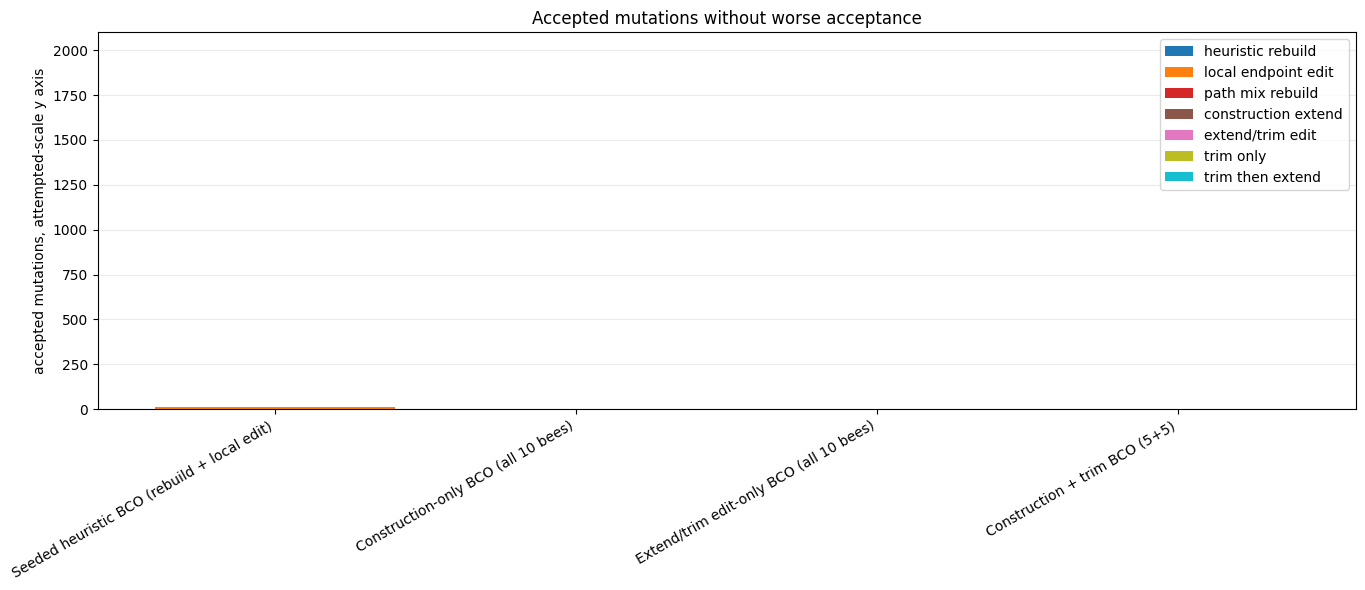

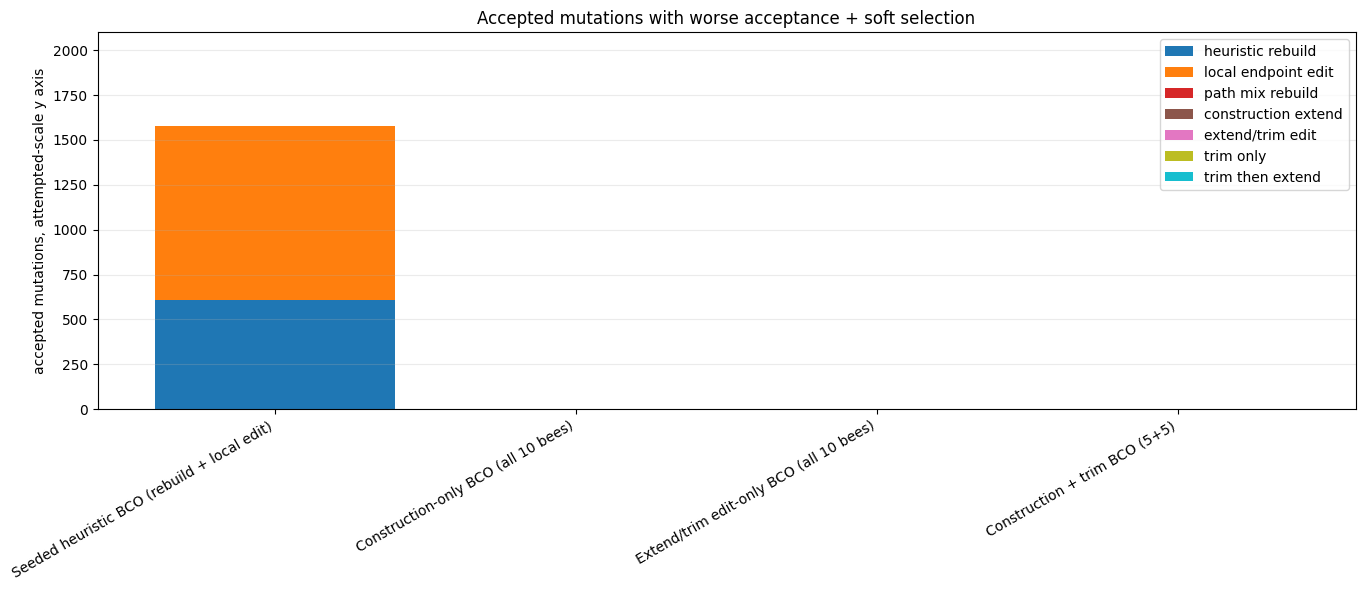

In [11]:
def plot_accepted_mutation_histogram(rows_df: pd.DataFrame, accept_key: str, title: str, y_max: float | None = None):
    accepted_cols = [f"accepted_{mutation_slug(type_name)}" for type_name in MUTATION_TYPE_KEYS]
    attempted_cols = [f"attempted_{mutation_slug(type_name)}" for type_name in MUTATION_TYPE_KEYS]
    mode_rows = rows_df[rows_df["accept_key"] == accept_key]
    plot_df = mode_rows.groupby(["variant_key", "variant"], sort=False)[accepted_cols].mean().reset_index()

    if y_max is None:
        attempted_df = rows_df.groupby(["accept_key", "variant_key"], sort=False)[attempted_cols].mean()
        y_max = float(attempted_df.sum(axis=1).max()) if not attempted_df.empty else 1.0
    y_max = max(float(y_max), 1.0)

    x = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(max(14, 1.35 * len(plot_df)), 6))
    bottom = np.zeros(len(plot_df))
    colors = plt.cm.tab10(np.linspace(0, 1, len(MUTATION_TYPE_KEYS)))
    for type_name, col, color in zip(MUTATION_TYPE_KEYS, accepted_cols, colors):
        values = plot_df[col].to_numpy(dtype=float)
        ax.bar(x, values, bottom=bottom, color=color, label=mutation_label(type_name))
        bottom += values

    ax.set_title(title)
    ax.set_ylabel("accepted mutations, attempted-scale y axis")
    ax.set_ylim(0, y_max * 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["variant"], rotation=30, ha="right")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


attempted_cols = [f"attempted_{mutation_slug(type_name)}" for type_name in MUTATION_TYPE_KEYS]
attempted_by_mode_variant = worse_accept_rows_df.groupby(["accept_key", "variant_key"], sort=False)[attempted_cols].mean()
accepted_plot_ymax = float(attempted_by_mode_variant.sum(axis=1).max()) if not attempted_by_mode_variant.empty else 1.0

plot_accepted_mutation_histogram(
    worse_accept_rows_df,
    "without_worse",
    "Accepted mutations without worse acceptance",
    y_max=accepted_plot_ymax,
)
plot_accepted_mutation_histogram(
    worse_accept_rows_df,
    "with_worse",
    "Accepted mutations with worse acceptance + soft selection",
    y_max=accepted_plot_ymax,
)


## 8b. NX Heuristic Dataset BCO Seed Sweep

This block repeats the same BCO worse-accept seed sweep on one graph from `examples/nx_heuristic_results_10r_len12`. The main Mumford0/Initial-LC sweep above is left unchanged.


In [12]:
# Dataset graph source for a separate BCO seed sweep on one graph only.
import pickle
import random

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

NX_SWEEP_RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
NX_SWEEP_RESULTS_DIR = ROOT_DIR / "examples" / "nx_heuristic_results_10r_len12"
NX_SWEEP_GRAPH_INDEX = 0


def load_single_nx_heuristic_graph_and_routes(raw_graphs_path, results_dir, graph_index):
    graph_index = int(graph_index)
    # raw_graphs_1000.pkl is a single pickle, so loading the file reads the
    # list, but this sweep uses only the selected graph and one route file.
    with Path(raw_graphs_path).open("rb") as file:
        graphs = pickle.load(file)
    graph = graphs[graph_index]

    graph_dir = Path(results_dir) / f"graph_{graph_index:04d}"
    route_path = graph_dir / f"lc_lc_graph_{graph_index:04d}_routes_routes.pkl"
    if not route_path.exists():
        matches = sorted(graph_dir.glob("lc_*_routes_routes.pkl"))
        if not matches:
            raise FileNotFoundError(route_path)
        route_path = matches[0]

    with route_path.open("rb") as file:
        routes = pickle.load(file)
    if isinstance(routes, list):
        routes = routes[0]
    routes = torch.as_tensor(routes, dtype=torch.long)
    if routes.ndim == 3 and routes.shape[0] == 1:
        routes = routes.squeeze(0)
    if routes.ndim != 2:
        raise ValueError(f"Expected routes with shape (n_routes, len), got {tuple(routes.shape)}")

    used_columns = (routes >= 0).any(dim=0).nonzero().flatten()
    route_width = int(used_columns[-1].item()) + 1 if used_columns.numel() else 1
    route_width = min(route_width, MAX_ROUTE_LEN)
    routes = routes[:, :route_width]

    route_batch = torch.full(
        (1, N_ROUTES, MAX_ROUTE_LEN),
        -1,
        dtype=torch.long,
    )
    n_copy_routes = min(N_ROUTES, routes.shape[0])
    n_copy_stops = min(MAX_ROUTE_LEN, routes.shape[1])
    route_batch[0, :n_copy_routes, :n_copy_stops] = routes[:n_copy_routes, :n_copy_stops]
    return graph, route_batch, route_path


(
    nx_sweep_graph,
    nx_sweep_initial_routes,
    nx_sweep_route_path,
) = load_single_nx_heuristic_graph_and_routes(
    NX_SWEEP_RAW_GRAPHS_PATH,
    NX_SWEEP_RESULTS_DIR,
    NX_SWEEP_GRAPH_INDEX,
)

nx_sweep_route_lengths = (nx_sweep_initial_routes > -1).sum(dim=-1)
nx_sweep_real_route_lengths = nx_sweep_route_lengths[nx_sweep_route_lengths > 0]
assert nx_sweep_initial_routes.shape == (1, N_ROUTES, MAX_ROUTE_LEN), nx_sweep_initial_routes.shape
assert int(nx_sweep_real_route_lengths.min().item()) == MAX_ROUTE_LEN, nx_sweep_real_route_lengths.tolist()
assert int(nx_sweep_real_route_lengths.max().item()) == MAX_ROUTE_LEN, nx_sweep_real_route_lengths.tolist()


def nx_graph_to_tensor_dataset(graph):
    n_nodes = graph[STOP_KEY].pos.shape[0]
    return {
        "node_locs": graph[STOP_KEY].pos[:n_nodes].detach().cpu(),
        "street_adj": graph.street_adj[:n_nodes, :n_nodes].detach().cpu(),
        "demand": graph.demand[:n_nodes, :n_nodes].detach().cpu(),
    }


def run_bco_on_nx_tensors(cfg, tensors, init_routes, mutation_counts_out=None):
    dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    use_neural_bees = cfg.get("neural_bees", False)
    prefix = "nx_dataset_neural_bco_" if use_neural_bees else "nx_dataset_bco_"
    device, run_name, _, cost_obj, bee_model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=prefix,
        weights_required=use_neural_bees,
    )
    force_linking_unlinked = cfg.get("force_linking_unlinked", False)
    if not use_neural_bees:
        bee_model = None
    elif bee_model is not None:
        bee_model.force_linking_unlinked = force_linking_unlinked
        bee_model.eval()

    n_type5_bees = int(cfg.get("n_type5_bees", 0))
    n_type6_bees = int(cfg.get("n_type6_bees", 0))
    n_type7_bees = int(cfg.get("n_type7_bees", 0))
    edit_model = build_edit_model(device) if (n_type5_bees > 0 or n_type6_bees > 0 or n_type7_bees > 0) else None
    mutation_counts_out = {} if mutation_counts_out is None else mutation_counts_out

    output = lrnu.test_method(
        bee_colony,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=init_routes,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        n_type1_bees=cfg.get("n_type1_bees", None),
        n_type2_bees=cfg.get("n_type2_bees", None),
        n_type4_bees=cfg.get("n_type4_bees", 0),
        n_type5_bees=n_type5_bees,
        n_type6_bees=n_type6_bees,
        n_type7_bees=n_type7_bees,
        bee_model=bee_model,
        edit_model=edit_model,
        force_linking_unlinked=force_linking_unlinked,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", 0.1),
        adjustment_degree_mode=cfg.get("adjustment_degree_mode", "current"),
        adjustment_degree_objective=cfg.get("adjustment_degree_objective", "raw"),
        adjustment_degree_target=cfg.get("adjustment_degree_target", 0.2),
        ignore_type4_max_route_len=cfg.get("ignore_type4_max_route_len", False),
        ignore_type5_max_route_len=cfg.get("ignore_type5_max_route_len", False),
        ignore_type6_max_route_len=cfg.get("ignore_type6_max_route_len", False),
        ignore_type7_max_route_len=cfg.get("ignore_type7_max_route_len", False),
        use_demand_weighted_route_selection=cfg.get("use_demand_weighted_route_selection", False),
        worse_accept_temperature=cfg.get("worse_accept_temperature", 0.0),
        worse_accept_decay=cfg.get("worse_accept_decay", 0.995),
        worse_accept_min_temperature=cfg.get("worse_accept_min_temperature", 0.001),
        worse_selection_temperature=cfg.get("worse_selection_temperature", 0.0),
        worse_selection_decay=cfg.get("worse_selection_decay", 0.995),
        worse_selection_min_temperature=cfg.get("worse_selection_min_temperature", 0.001),
        worse_selection_uniform_mix=cfg.get("worse_selection_uniform_mix", 0.05),
        worse_selection_elite_count=cfg.get("worse_selection_elite_count", 1),
        mutation_counts_out=mutation_counts_out,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor, mutation_counts_out


nx_sweep_tensors = nx_graph_to_tensor_dataset(nx_sweep_graph)
print(
    f"NX dataset sweep graph={NX_SWEEP_GRAPH_INDEX}, "
    f"nodes={nx_sweep_graph[STOP_KEY].num_nodes}, "
    f"seed_routes_shape={tuple(nx_sweep_initial_routes.shape)}, route_file={nx_sweep_route_path.name}"
)


NX dataset sweep graph=0, nodes=50, seed_routes_shape=(1, 10, 12), route_file=lc_nx_heuristic_graph_0000_routes_routes.pkl


In [13]:
NX_DATASET_SWEEP_SEEDS = WORSE_ACCEPT_SEEDS
NX_DATASET_SWEEP_ACCEPT_EXPERIMENTS = WORSE_ACCEPT_EXPERIMENTS
NX_DATASET_SWEEP_VARIANT_KEYS = [variant["key"] for variant in BCO_VARIANTS]
NX_DATASET_SWEEP_DUMP_ROUTES = False


def run_nx_dataset_bco_seed_sweep(
    seeds=None,
    accept_experiments=None,
    variant_keys=None,
    mode_key="uniform",
):
    if seeds is None:
        seeds = NX_DATASET_SWEEP_SEEDS
    if accept_experiments is None:
        accept_experiments = NX_DATASET_SWEEP_ACCEPT_EXPERIMENTS
    if variant_keys is None:
        variant_keys = NX_DATASET_SWEEP_VARIANT_KEYS

    selected_variants = [
        variant for variant in BCO_VARIANTS if variant["key"] in set(variant_keys)
    ]
    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]
    rows = []
    results = {}
    total_runs = len(accept_experiments) * len(selected_variants) * len(seeds)
    run_idx = 0

    for accept_cfg in accept_experiments:
        accept_key = accept_cfg["key"]
        results[accept_key] = {}
        for variant in selected_variants:
            variant_results = []
            for seed in seeds:
                run_idx += 1
                random.seed(int(seed))
                np.random.seed(int(seed))
                torch.manual_seed(int(seed))
                print(
                    f"[nx {run_idx}/{total_runs}] graph={NX_SWEEP_GRAPH_INDEX} | "
                    f"{accept_key} | {variant['key']} | seed={seed}"
                )
                cfg = build_bco_cfg(
                    run_name=route_selection_run_name(
                        f"nx_dataset_g{NX_SWEEP_GRAPH_INDEX}_{variant['run_name']}_{accept_key}_seed{seed}",
                        mode_key,
                    ),
                    n_routes=N_ROUTES,
                    min_route_len=MIN_ROUTE_LEN,
                    max_route_len=MAX_ROUTE_LEN,
                    use_neural_bees=variant["use_neural_bees"],
                    n_type1_bees=variant["n_type1_bees"],
                    n_type2_bees=variant["n_type2_bees"],
                    n_type4_bees=variant["n_type4_bees"],
                    n_type5_bees=variant.get("n_type5_bees", 0),
                    n_type6_bees=variant.get("n_type6_bees", 0),
                    n_type7_bees=variant.get("n_type7_bees", 0),
                    ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                    ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                    ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                    ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                    use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
                    worse_accept_temperature=accept_cfg["temperature"],
                    worse_accept_decay=accept_cfg["decay"],
                    worse_accept_min_temperature=accept_cfg["min_temperature"],
                    worse_selection_temperature=accept_cfg["selection_temperature"],
                    worse_selection_decay=accept_cfg["selection_decay"],
                    worse_selection_min_temperature=accept_cfg["selection_min_temperature"],
                    worse_selection_uniform_mix=accept_cfg["selection_uniform_mix"],
                    worse_selection_elite_count=accept_cfg["selection_elite_count"],
                )
                cfg.experiment.seed = int(seed)

                mutation_counts = {}
                run_name, metrics, unserved_demand, routes, mutation_counts = run_bco_on_nx_tensors(
                    cfg,
                    nx_sweep_tensors,
                    init_routes=nx_sweep_initial_routes,
                    mutation_counts_out=mutation_counts,
                )
                if NX_DATASET_SWEEP_DUMP_ROUTES:
                    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

                attempted = mutation_stat_bucket(mutation_counts, "attempted")
                accepted = mutation_stat_bucket(mutation_counts, "accepted")
                worse_accepted = mutation_stat_bucket(mutation_counts, "worse_accepted")
                selection_stats = selection_stat_bucket(mutation_counts)
                row = summarize_run(
                    f"{variant['summary_label']} [NX dataset, {accept_cfg['label']}, seed={seed}]",
                    metrics,
                    routes,
                )
                row.update({
                    "graph_source": "nx_heuristic_dataset",
                    "graph_index": int(NX_SWEEP_GRAPH_INDEX),
                    "accept_key": accept_key,
                    "accept_mode": accept_cfg["label"],
                    "worse_accept_temperature": accept_cfg["temperature"],
                    "worse_accept_decay": accept_cfg["decay"],
                    "worse_accept_min_temperature": accept_cfg["min_temperature"],
                    "worse_selection_temperature": accept_cfg["selection_temperature"],
                    "worse_selection_decay": accept_cfg["selection_decay"],
                    "worse_selection_min_temperature": accept_cfg["selection_min_temperature"],
                    "worse_selection_uniform_mix": accept_cfg["selection_uniform_mix"],
                    "worse_selection_elite_count": accept_cfg["selection_elite_count"],
                    "seed": int(seed),
                    "route_selection": mode_cfg["label"],
                    "variant_key": variant["key"],
                    "variant": variant["summary_label"],
                    "heuristic_rebuild_bees": variant["n_type1_bees"],
                    "local_endpoint_edit_bees": bco_variant_type2_bees(variant),
                    "construction_extend_bees": variant["n_type4_bees"],
                    "extend_trim_edit_bees": variant.get("n_type5_bees", 0),
                    "trim_only_bees": variant.get("n_type6_bees", 0),
                    "trim_then_extend_bees": variant.get("n_type7_bees", 0),
                    "attempted_total": sum(attempted.values()),
                    "accepted_total": sum(accepted.values()),
                    "worse_accepted_total": sum(worse_accepted.values()),
                    "selection_parent_copies": selection_stats["parent_copies"],
                    "selection_nonbest_parent_copies": selection_stats["nonbest_parent_copies"],
                    "selection_worse_parent_copies": selection_stats["worse_parent_copies"],
                })
                for type_name in MUTATION_TYPE_KEYS:
                    slug = mutation_slug(type_name)
                    row[f"attempted_{slug}"] = attempted[type_name]
                    row[f"accepted_{slug}"] = accepted[type_name]
                    row[f"worse_accepted_{slug}"] = worse_accepted[type_name]
                rows.append(row)
                variant_results.append({
                    "seed": int(seed),
                    "run_name": run_name,
                    "metrics": metrics,
                    "unserved_demand": unserved_demand,
                    "routes": routes,
                    "routes_tensor": routes,
                    "mutation_counts": mutation_counts,
                })
            results[accept_key][variant["key"]] = variant_results

    rows_df = pd.DataFrame(rows)
    return {
        "rows_df": rows_df,
        "results": results,
        "seeds": list(seeds),
        "accept_experiments": accept_experiments,
        "variant_keys": list(variant_keys),
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
        "graph_source": "nx_heuristic_dataset",
        "graph_index": int(NX_SWEEP_GRAPH_INDEX),
        "init_routes": nx_sweep_initial_routes,
        "tensors": nx_sweep_tensors,
    }


nx_dataset_bco_seed_sweep = run_nx_dataset_bco_seed_sweep()
nx_dataset_bco_rows_df = nx_dataset_bco_seed_sweep["rows_df"]
nx_dataset_bco_summary_df, nx_dataset_bco_comparison_df = summarize_worse_accept_seed_sweep(
    nx_dataset_bco_rows_df
)


[nx 1/8] graph=0 | without_worse | seeded_heuristic | seed=0
[nx_dataset_g0_seeded_bco_heuristic_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[nx 2/8] graph=0 | without_worse | construction_only | seed=0
[nx_dataset_g0_seeded_bco_construction_only_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=10 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[nx 3/8] graph=0 | without_worse | extend_trim_edit_only | seed=0
[nx_dataset_g0_seeded_bco_extend_trim_edit_only_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=10 trim_only=0 trim_then_extend=0 (total=10)
[nx 4/8] graph=0 | without_worse | construction_trim_split_5_5 | seed=0
[nx_dataset_g0_seeded_bco_construction_trim_split_5_5_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=5 extend_trim

,variant_key,variant,accept_key,accept_mode,n_seeds,mean_cost,std_cost,mean_cost_demand_term,mean_cost_route_term,mean_cost_connectivity_term,...,std_ATT,mean_RTT,std_RTT,mean_unserved,mean_routes,mean_accepted_total,mean_worse_accepted_total,mean_selection_parent_copies,mean_selection_nonbest_parent_copies,mean_selection_worse_parent_copies
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),without_worse,without worse acceptance,1,0.4734,NaN,0.1649,0.2476,0.0608,...,NaN,659.5107,NaN,26.2253,10.0,116.0,0.0,390.0,119.0,10.0
1,construction_only,Construction-only BCO (all 10 bees),without_worse,without worse acceptance,1,2.4066,NaN,0.2579,0.4543,0.0556,...,NaN,1209.7654,NaN,27.8733,10.0,0.0,0.0,0.0,0.0,0.0
2,extend_trim_edit_only,Extend/trim edit-only BCO (all 10 bees),without_worse,without worse acceptance,1,0.5894,NaN,0.1604,0.3645,0.0645,...,NaN,970.6749,NaN,14.3750,10.0,84.0,0.0,80.0,38.0,10.0
3,construction_trim_split_5_5,Construction + trim BCO (5+5),without_worse,without worse acceptance,1,1.4071,NaN,0.2185,0.2248,0.0680,...,NaN,598.5689,NaN,38.6336,10.0,91.0,0.0,250.0,108.0,14.0
4,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),with_worse,with worse acceptance + soft selection (T0=1),1,0.5437,NaN,0.1541,0.3281,0.0615,...,NaN,873.6962,NaN,6.7436,10.0,1300.0,941.0,1000.0,772.0,289.0
5,construction_only,Construction-only BCO (all 10 bees),with_worse,with worse acceptance + soft selection (T0=1),1,2.4066,NaN,0.2579,0.4543,0.0556,...,NaN,1209.7654,NaN,27.8733,10.0,0.0,0.0,1000.0,0.0,0.0
6,extend_trim_edit_only,Extend/trim edit-only BCO (all 10 bees),with_worse,with worse acceptance + soft selection (T0=1),1,0.5835,NaN,0.2046,0.3019,0.0770,...,NaN,804.0081,NaN,36.2440,10.0,103.0,20.0,1000.0,287.0,77.0
7,construction_trim_split_5_5,Construction + trim BCO (5+5),with_worse,with worse acceptance + soft selection (T0=1),1,1.4151,NaN,0.2155,0.2356,0.0681,...,NaN,627.4495,NaN,32.7652,10.0,342.0,213.0,1000.0,668.0,267.0


,variant_key,variant,mean_cost_without_worse,mean_cost_with_worse,mean_cost_demand_term_without_worse,mean_cost_demand_term_with_worse,mean_cost_route_term_without_worse,mean_cost_route_term_with_worse,mean_cost_connectivity_term_without_worse,mean_cost_connectivity_term_with_worse,...,mean_selection_nonbest_parent_copies_without_worse,mean_selection_nonbest_parent_copies_with_worse,mean_selection_worse_parent_copies_without_worse,mean_selection_worse_parent_copies_with_worse,delta_cost_with_minus_without,delta_ATT_with_minus_without,delta_RTT_with_minus_without,delta_accepted_total_with_minus_without,delta_nonbest_parent_copies_with_minus_without,delta_worse_parent_copies_with_minus_without
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),0.4734,0.5437,0.1649,0.1541,0.2476,0.3281,0.0608,0.0615,...,119.0,772.0,10.0,289.0,0.0703,-2.8775,214.1855,1184.0,653.0,279.0
1,construction_only,Construction-only BCO (all 10 bees),2.4066,2.4066,0.2579,0.2579,0.4543,0.4543,0.0556,0.0556,...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0,0.0
2,extend_trim_edit_only,Extend/trim edit-only BCO (all 10 bees),0.5894,0.5835,0.1604,0.2046,0.3645,0.3019,0.0645,0.0770,...,38.0,287.0,10.0,77.0,-0.0058,11.7817,-166.6668,19.0,249.0,67.0
3,construction_trim_split_5_5,Construction + trim BCO (5+5),1.4071,1.4151,0.2185,0.2155,0.2248,0.2356,0.0680,0.0681,...,108.0,668.0,14.0,267.0,0.0080,-0.8478,28.8806,251.0,560.0,253.0


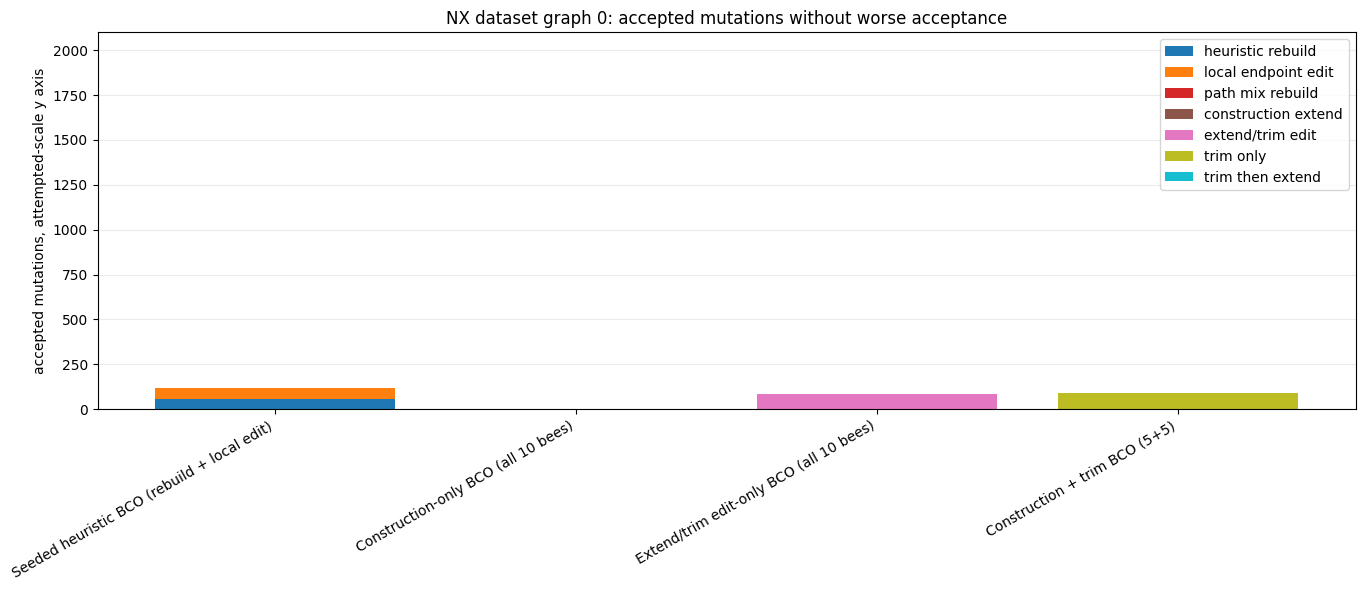

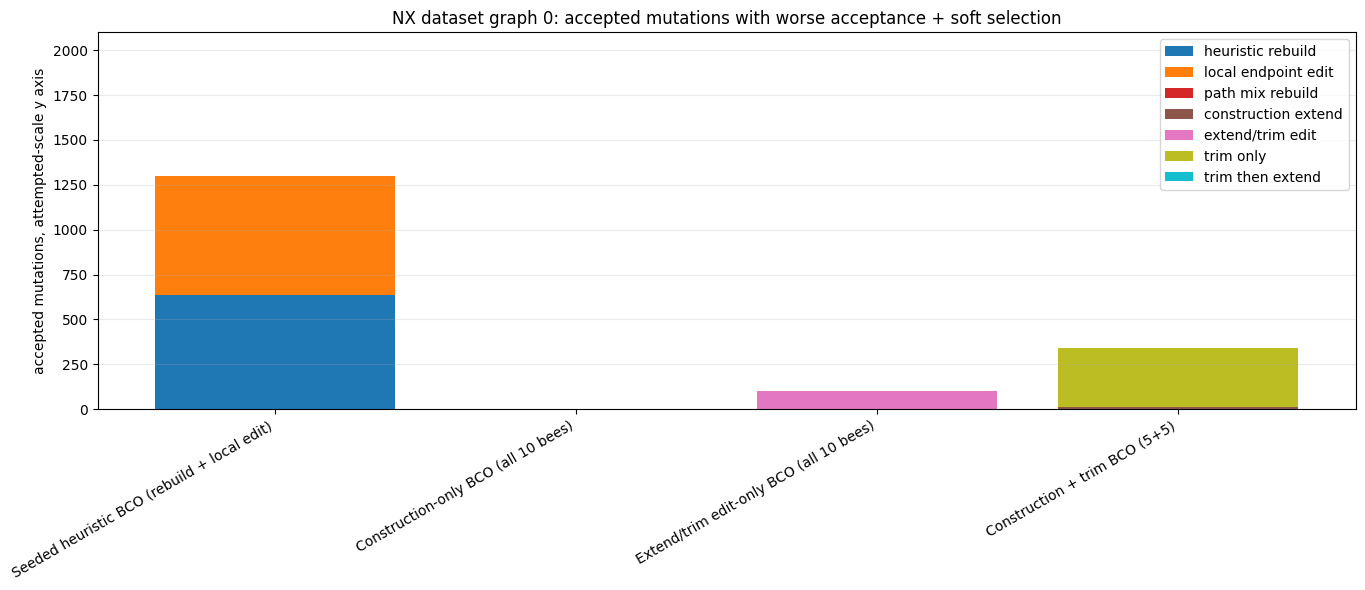

In [14]:
display(nx_dataset_bco_summary_df.round(4))
display(nx_dataset_bco_comparison_df.round(4))

nx_attempted_cols = [f"attempted_{mutation_slug(type_name)}" for type_name in MUTATION_TYPE_KEYS]
nx_attempted_by_mode_variant = nx_dataset_bco_rows_df.groupby(
    ["accept_key", "variant_key"], sort=False
)[nx_attempted_cols].mean()
nx_accepted_plot_ymax = (
    float(nx_attempted_by_mode_variant.sum(axis=1).max())
    if not nx_attempted_by_mode_variant.empty else 1.0
)

plot_accepted_mutation_histogram(
    nx_dataset_bco_rows_df,
    "without_worse",
    f"NX dataset graph {NX_SWEEP_GRAPH_INDEX}: accepted mutations without worse acceptance",
    y_max=nx_accepted_plot_ymax,
)
plot_accepted_mutation_histogram(
    nx_dataset_bco_rows_df,
    "with_worse",
    f"NX dataset graph {NX_SWEEP_GRAPH_INDEX}: accepted mutations with worse acceptance + soft selection",
    y_max=nx_accepted_plot_ymax,
)


## 9. Single-Seed Mutation Type Statistics


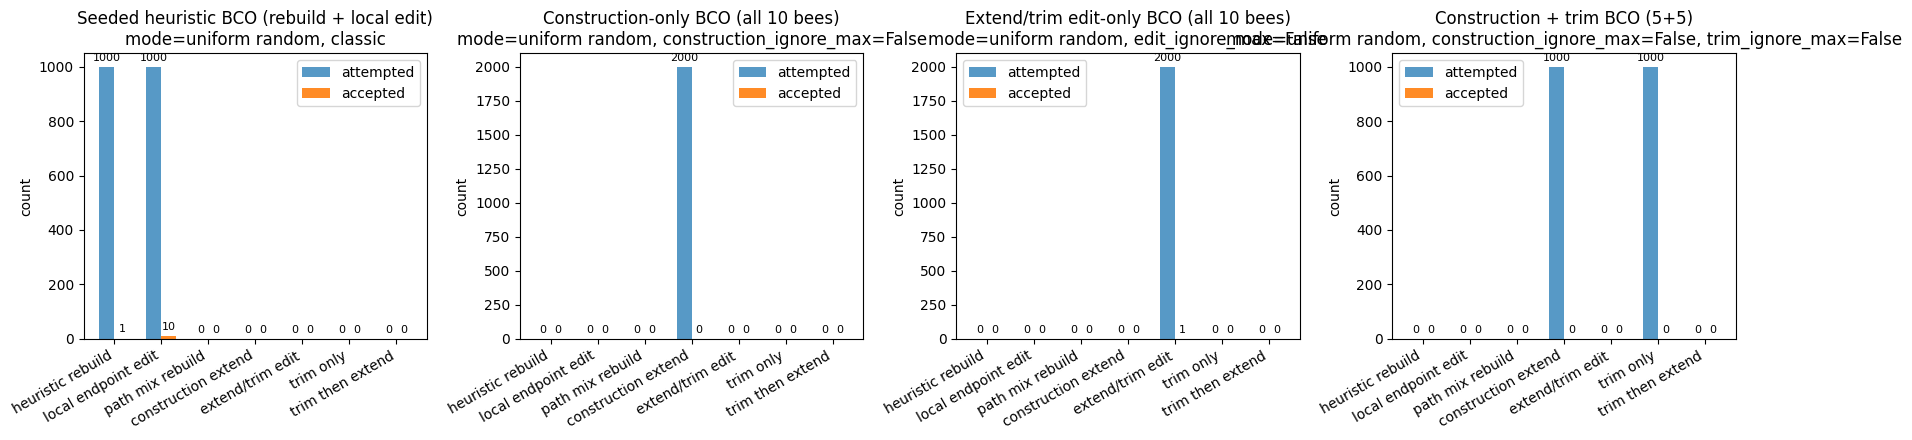

In [15]:
def plot_mutation_counts(mutation_stats: dict, title: str, ax=None):
    attempted = mutation_stat_bucket(mutation_stats, "attempted")
    accepted = mutation_stat_bucket(mutation_stats, "accepted")
    worse_accepted = mutation_stat_bucket(mutation_stats, "worse_accepted")
    if not any(attempted.values()) and not any(accepted.values()) and not any(worse_accepted.values()):
        print(f"No mutation stats for '{title}'.")
        return

    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(6.5, 4))

    labels = list(attempted.keys())
    display_labels = [mutation_label(type_name) for type_name in labels]
    xs = np.arange(len(labels))
    series = [
        ("attempted", attempted, "tab:blue", 0.75),
        ("accepted", accepted, "tab:orange", 0.9),
    ]
    if any(worse_accepted.values()):
        series.append(("worse accepted", worse_accepted, "tab:red", 0.85))

    width = min(0.8 / len(series), 0.32)
    offsets = (np.arange(len(series)) - (len(series) - 1) / 2) * width
    all_vals = []
    bar_groups = []
    for offset, (label, values, color, alpha) in zip(offsets, series):
        vals = [values[type_name] for type_name in labels]
        all_vals.extend(vals)
        bar_groups.append(
            ax.bar(xs + offset, vals, width, color=color, alpha=alpha, label=label)
        )

    ax.set_xticks(xs)
    ax.set_xticklabels(display_labels, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel("count")
    ax.legend()

    ymax = max(all_vals + [1])
    for bars in bar_groups:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + ymax * 0.015,
                    f"{int(height)}",
                    ha="center", va="bottom", fontsize=8)

    if show:
        plt.tight_layout()
        plt.show()


mode_keys = list(BCO_ROUTE_SELECTION_MODES.keys())
fig, axes = plt.subplots(len(mode_keys), len(BCO_VARIANTS), figsize=(4.4 * len(BCO_VARIANTS), 4.5 * len(mode_keys)), squeeze=False)
for row_idx, mode_key in enumerate(mode_keys):
    mode_label = route_selection_mode_label(mode_key)
    for col_idx, variant in enumerate(BCO_VARIANTS):
        result = bco_experiment_results[mode_key][variant["key"]]
        ignore_bits = []
        if variant.get("n_type4_bees", 0):
            ignore_bits.append(f"construction_ignore_max={BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type5_bees", 0):
            ignore_bits.append(f"edit_ignore_max={BCO_EDIT_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type6_bees", 0):
            ignore_bits.append(f"trim_ignore_max={BCO_TRIM_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type7_bees", 0):
            ignore_bits.append(f"trim_extend_ignore_max={BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN}")
        ignore_text = ", ".join(ignore_bits) if ignore_bits else "classic"
        title = (
            f"{variant['summary_label']}\n"
            f"mode={mode_label}, {ignore_text}"
        )
        plot_mutation_counts(result["mutation_counts"], title, ax=axes[row_idx, col_idx])
plt.tight_layout()
plt.show()


In [16]:
from IPython.display import display

comparison_rows = [
    {
        **summarize_run("Initial LC", lc_base_metrics, lc_base_routes),
        "route_selection": "n/a",
        "variant": "Initial LC",
    },
    {
        **summarize_run("Seeded LC", lc_seeded_metrics, lc_seeded_routes),
        "route_selection": "n/a",
        "variant": "Seeded LC",
    },
]

mutation_rows = []

for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    for variant in BCO_VARIANTS:
        result = bco_experiment_results[mode_key][variant["key"]]
        row = summarize_run(
            f"{variant['summary_label']} [{mode_cfg['label']}]",
            result["metrics"],
            result["routes_tensor"],
        )
        row["route_selection"] = mode_cfg["label"]
        row["variant"] = variant["summary_label"]
        comparison_rows.append(row)

        attempted = mutation_stat_bucket(result["mutation_counts"], "attempted")
        accepted = mutation_stat_bucket(result["mutation_counts"], "accepted")
        worse_accepted = mutation_stat_bucket(result["mutation_counts"], "worse_accepted")
        mutation_row = {
            "route_selection": mode_cfg["label"],
            "variant": variant["summary_label"],
            "heuristic_rebuild_bees": variant["n_type1_bees"],
            "local_endpoint_edit_bees": bco_variant_type2_bees(variant),
            "construction_extend_bees": variant["n_type4_bees"],
            "extend_trim_edit_bees": variant.get("n_type5_bees", 0),
            "trim_only_bees": variant.get("n_type6_bees", 0),
            "trim_then_extend_bees": variant.get("n_type7_bees", 0),
        }
        for type_name in MUTATION_TYPE_KEYS:
            slug = mutation_slug(type_name)
            mutation_row[f"attempted_{slug}"] = attempted[type_name]
            mutation_row[f"accepted_{slug}"] = accepted[type_name]
            mutation_row[f"worse_accepted_{slug}"] = worse_accepted[type_name]
        mutation_rows.append(mutation_row)

comparison_df = pd.DataFrame(comparison_rows)
seeded_lc_row = comparison_df.loc[comparison_df["method"] == "Seeded LC"].iloc[0]
comparison_df["delta_cost_vs_seeded_lc"] = comparison_df["cost"] - seeded_lc_row["cost"]
comparison_df["delta_ATT_vs_seeded_lc"] = comparison_df["ATT"] - seeded_lc_row["ATT"]
comparison_df["delta_RTT_vs_seeded_lc"] = comparison_df["RTT"] - seeded_lc_row["RTT"]
comparison_df = comparison_df[[
    "method",
    "route_selection",
    "variant",
    "cost",
    "cost_demand_term",
    "cost_route_term",
    "cost_connectivity_term",
    "cost_penalty_term",
    "ATT",
    "RTT",
    "median_connectivity",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "# routes",
    "delta_cost_vs_seeded_lc",
    "delta_ATT_vs_seeded_lc",
    "delta_RTT_vs_seeded_lc",
]]
bco_mutation_comparison_df = pd.DataFrame(mutation_rows)

display(comparison_df.round(4))
display(bco_mutation_comparison_df)


,method,route_selection,variant,cost,cost_demand_term,cost_route_term,cost_connectivity_term,cost_penalty_term,ATT,RTT,median_connectivity,$d_{un}$,# disconnected node pairs,# stops out of bounds,# routes,delta_cost_vs_seeded_lc,delta_ATT_vs_seeded_lc,delta_RTT_vs_seeded_lc
0,Initial LC,n/a,Initial LC,0.7575,0.2804,0.3833,0.0939,0.0,22.0886,302.0,16.2000,3.7176,0.0,0.0,10,0.0000,0.0000,0.0
1,Seeded LC,n/a,Seeded LC,0.7575,0.2804,0.3833,0.0939,0.0,22.0886,302.0,16.2000,3.7176,0.0,0.0,10,0.0000,0.0000,0.0
2,Seeded heuristic BCO (rebuild + local edit) [u...,uniform random,Seeded heuristic BCO (rebuild + local edit),0.7136,0.2893,0.3275,0.0968,0.0,22.7968,258.0,17.0667,7.4965,0.0,0.0,10,-0.0440,0.7082,-44.0
3,Construction-only BCO (all 10 bees) [uniform r...,uniform random,Construction-only BCO (all 10 bees),0.7575,0.2804,0.3833,0.0939,0.0,22.0886,302.0,16.2000,3.7176,0.0,0.0,10,0.0000,0.0000,0.0
4,Extend/trim edit-only BCO (all 10 bees) [unifo...,uniform random,Extend/trim edit-only BCO (all 10 bees),0.7570,0.2711,0.3960,0.0899,0.0,21.3581,312.0,15.8000,3.9251,0.0,0.0,10,-0.0006,-0.7305,10.0
5,Construction + trim BCO (5+5) [uniform random],uniform random,Construction + trim BCO (5+5),0.7575,0.2804,0.3833,0.0939,0.0,22.0886,302.0,16.2000,3.7176,0.0,0.0,10,0.0000,0.0000,0.0


,route_selection,variant,heuristic_rebuild_bees,local_endpoint_edit_bees,construction_extend_bees,extend_trim_edit_bees,trim_only_bees,trim_then_extend_bees,attempted_heuristic_rebuild,accepted_heuristic_rebuild,...,worse_accepted_construction_extend,attempted_extend_trim_edit,accepted_extend_trim_edit,worse_accepted_extend_trim_edit,attempted_trim_only,accepted_trim_only,worse_accepted_trim_only,attempted_trim_then_extend,accepted_trim_then_extend,worse_accepted_trim_then_extend
0,uniform random,Seeded heuristic BCO (rebuild + local edit),5,5,0,0,0,0,1000,1,...,0,0,0,0,0,0,0,0,0,0
1,uniform random,Construction-only BCO (all 10 bees),0,0,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,uniform random,Extend/trim edit-only BCO (all 10 bees),0,0,0,10,0,0,0,0,...,0,2000,1,0,0,0,0,0,0,0
3,uniform random,Construction + trim BCO (5+5),0,0,5,0,5,0,0,0,...,0,0,0,0,1000,0,0,0,0,0


## 10. Route Change Visualization

The initial LC solution is used as the reference. Figures are generated separately for `without_worse` and `with_worse`; each title includes both absolute metrics and the weighted cost terms used in the summed objective.


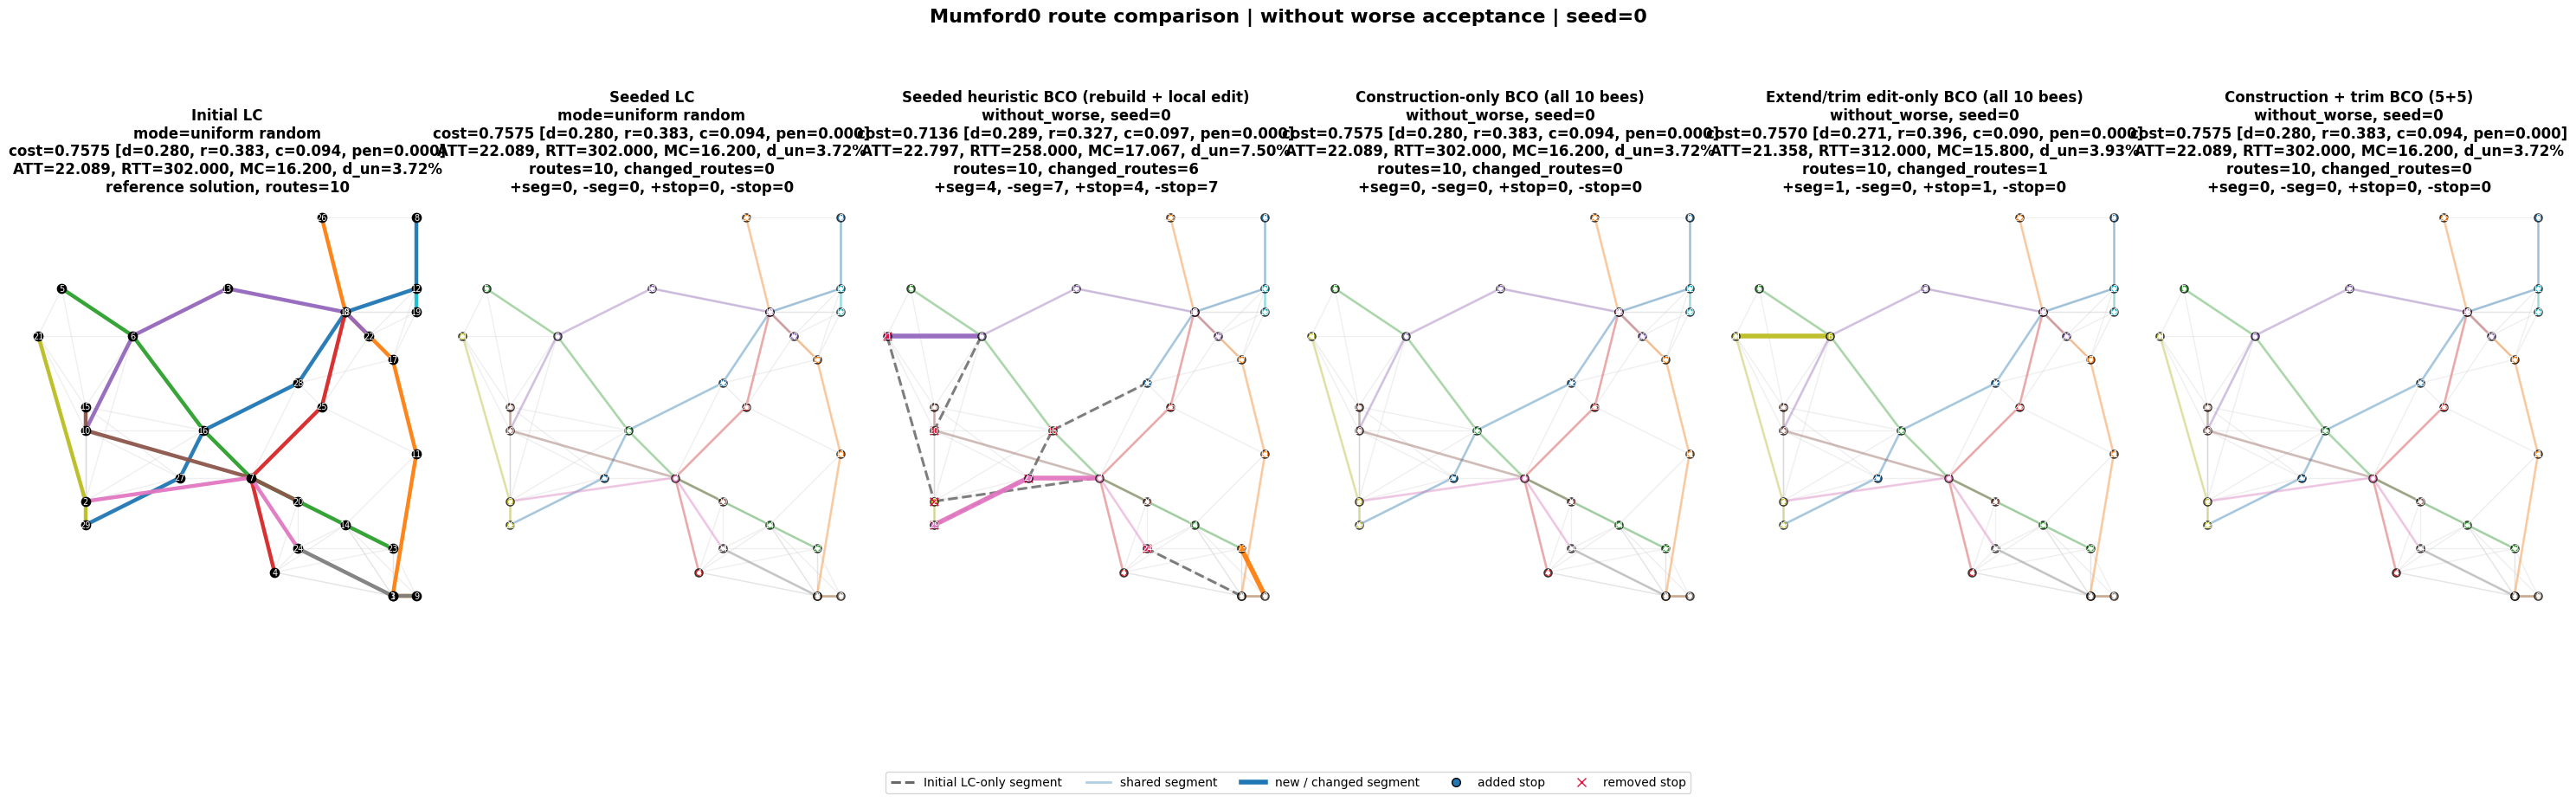

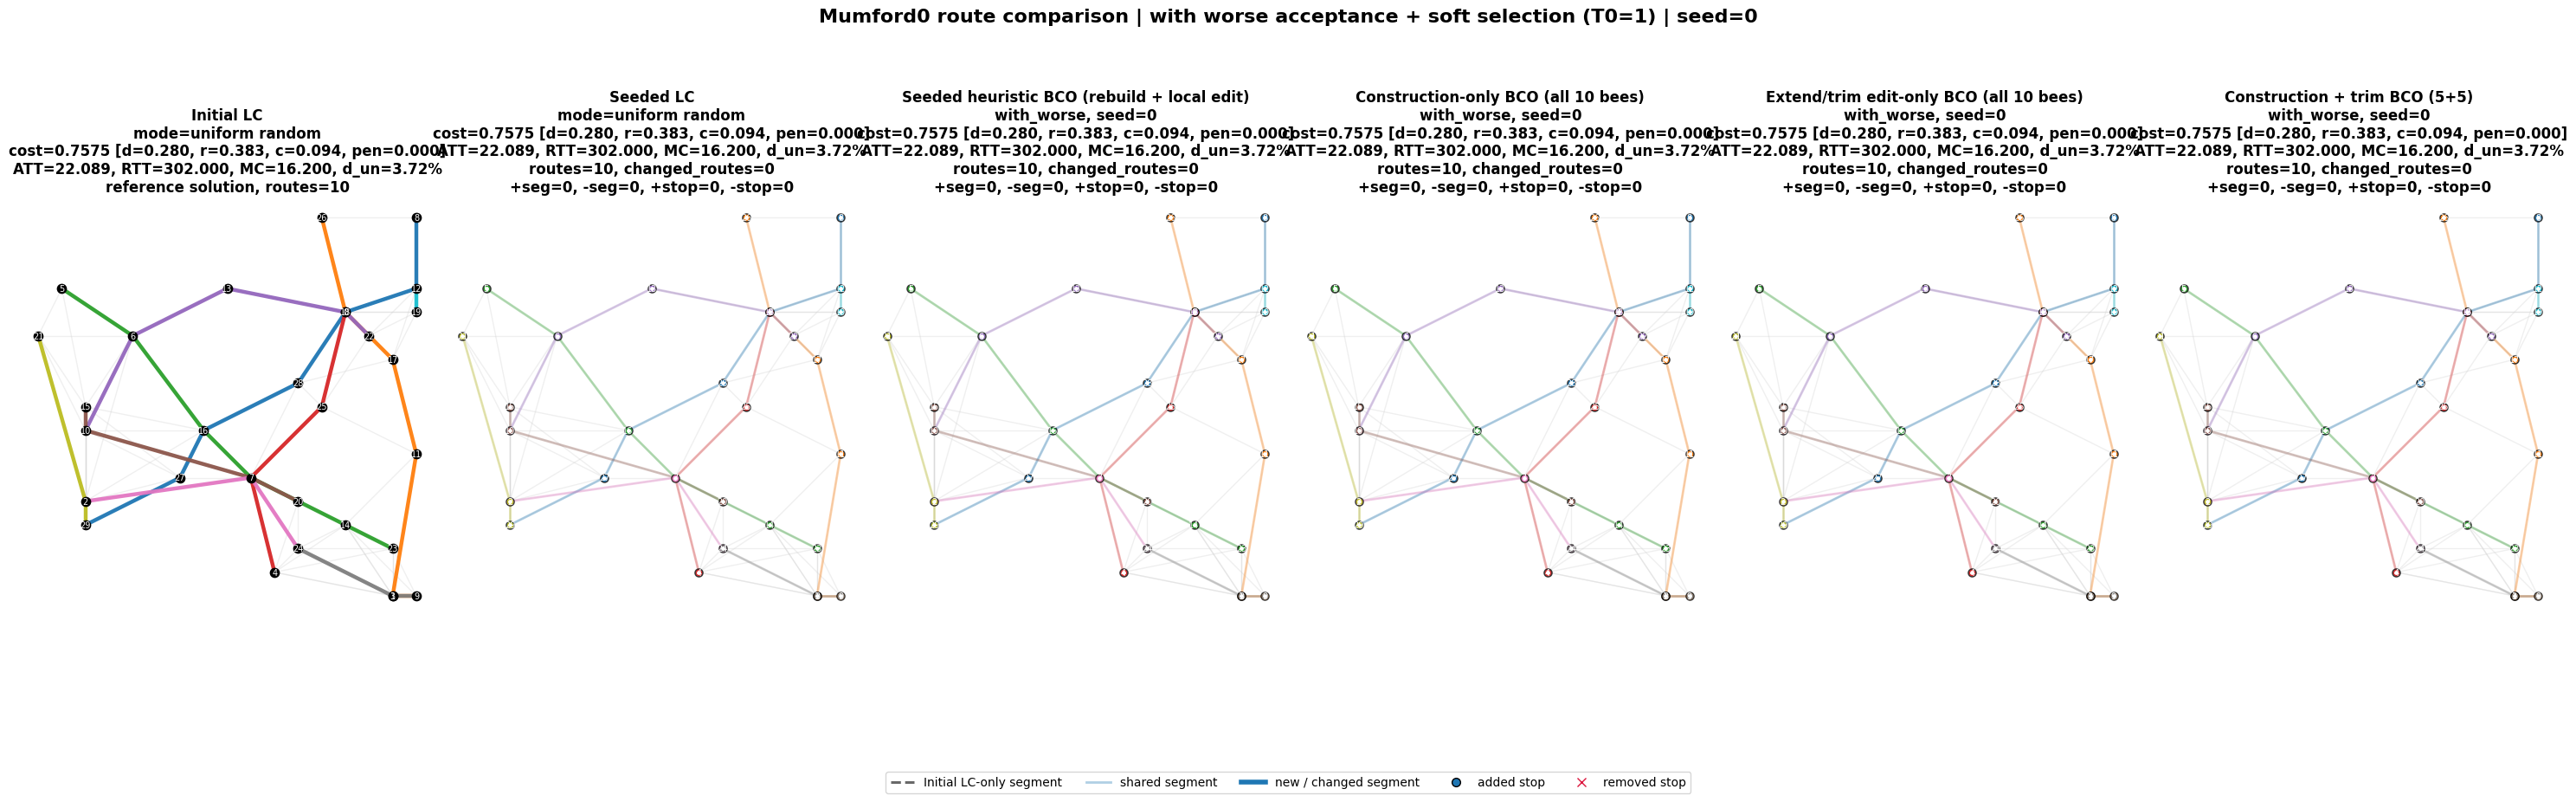

In [17]:
from matplotlib.lines import Line2D


def get_first_route_set(routes):
    routes = as_route_tensor(routes)
    if routes.ndim == 3:
        return routes[0]
    return routes


def route_to_list(route_tensor):
    return [int(x) for x in route_tensor.tolist() if x != -1]


def route_edge_list(route):
    return [(route[i], route[i + 1]) for i in range(len(route) - 1)]


def undirected_edge_key(edge):
    u, v = edge
    return tuple(sorted((u, v)))


def draw_street_graph(ax, coords, street_adj):
    n_nodes = coords.shape[0]
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
                ax.plot(
                    [coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1,
                )


def plot_edges(ax, coords, edges, *, color, linewidth, alpha, linestyle="-", zorder=3):
    for u, v in edges:
        ax.plot(
            [coords[u, 0], coords[v, 0]],
            [coords[u, 1], coords[v, 1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )


def summarize_route_changes(routes, reference_routes):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    summary = {
        "changed_routes": 0,
        "added_edges": 0,
        "removed_edges": 0,
        "added_stops": 0,
        "removed_stops": 0,
    }

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []

        route_edges = {undirected_edge_key(edge) for edge in route_edge_list(route)}
        reference_edges = {undirected_edge_key(edge) for edge in route_edge_list(reference)}
        route_nodes = set(route)
        reference_nodes = set(reference)

        added_edges = route_edges - reference_edges
        removed_edges = reference_edges - route_edges
        added_stops = route_nodes - reference_nodes
        removed_stops = reference_nodes - route_nodes

        if added_edges or removed_edges or added_stops or removed_stops:
            summary["changed_routes"] += 1
        summary["added_edges"] += len(added_edges)
        summary["removed_edges"] += len(removed_edges)
        summary["added_stops"] += len(added_stops)
        summary["removed_stops"] += len(removed_stops)

    return summary


def plot_plain_route_set(ax, routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, routes.shape[0])))
    for idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        if len(route) < 2:
            continue
        color = colors[idx % len(colors)]
        plot_edges(
            ax,
            coords,
            route_edge_list(route),
            color=color,
            linewidth=3.2,
            alpha=0.95,
            zorder=3,
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=55, zorder=5)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=6)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def plot_route_diff(ax, routes, reference_routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, max(routes.shape[0], reference_routes.shape[0]))))
    n_routes = max(routes.shape[0], reference_routes.shape[0])

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []
        color = colors[idx % len(colors)]

        route_edges_in_order = route_edge_list(route)
        reference_edges_in_order = route_edge_list(reference)
        route_edge_keys = {undirected_edge_key(edge) for edge in route_edges_in_order}
        reference_edge_keys = {undirected_edge_key(edge) for edge in reference_edges_in_order}

        shared_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) in reference_edge_keys]
        added_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) not in reference_edge_keys]
        removed_edges = [edge for edge in reference_edges_in_order if undirected_edge_key(edge) not in route_edge_keys]

        if removed_edges:
            plot_edges(
                ax,
                coords,
                removed_edges,
                color="dimgray",
                linewidth=2.2,
                alpha=0.85,
                linestyle="--",
                zorder=2,
            )
        if shared_edges:
            plot_edges(
                ax,
                coords,
                shared_edges,
                color=color,
                linewidth=2.0,
                alpha=0.35,
                zorder=3,
            )
        if added_edges:
            plot_edges(
                ax,
                coords,
                added_edges,
                color=color,
                linewidth=4.0,
                alpha=0.95,
                zorder=4,
            )

        route_nodes = set(route)
        reference_nodes = set(reference)
        shared_nodes = sorted(route_nodes & reference_nodes)
        added_nodes = sorted(route_nodes - reference_nodes)
        removed_nodes = sorted(reference_nodes - route_nodes)

        if shared_nodes:
            ax.scatter(coords[shared_nodes, 0], coords[shared_nodes, 1], s=20, facecolors="white", edgecolors=[color], linewidths=1.0, zorder=5)
        if added_nodes:
            ax.scatter(coords[added_nodes, 0], coords[added_nodes, 1], s=40, c=[color], edgecolors="black", linewidths=0.5, zorder=6)
        if removed_nodes:
            ax.scatter(coords[removed_nodes, 0], coords[removed_nodes, 1], s=45, c="crimson", marker="x", linewidths=1.4, zorder=6)

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=45, alpha=0.65, zorder=4)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=7)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def get_worse_plot_result(sweep_results: dict, accept_key: str, variant_key: str, seed: int):
    variant_results = sweep_results["results"][accept_key][variant_key]
    for result in variant_results:
        if int(result["seed"]) == int(seed):
            return result
    return variant_results[0]


coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
mode_keys = ["uniform"]
worse_plot_sweep = worse_accept_seed_sweep
WORSE_ROUTE_PLOT_SEED = int(worse_plot_sweep["seeds"][0])

style_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="Initial LC-only segment"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new / changed segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]

for accept_cfg in WORSE_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    n_comparison_cols = 2 + len(BCO_VARIANTS)
    fig, axes = plt.subplots(
        len(mode_keys),
        n_comparison_cols,
        figsize=(4.9 * n_comparison_cols, 9 * len(mode_keys)),
        squeeze=False,
        constrained_layout=True,
    )
    for row_idx, mode_key in enumerate(mode_keys):
        mode_label = route_selection_mode_label(mode_key)
        comparison_rows = [
            {
                "label": f"Initial LC\nmode={mode_label}",
                "routes": lc_base_routes,
                "metrics": lc_base_metrics,
                "is_reference": True,
            },
            {
                "label": f"Seeded LC\nmode={mode_label}",
                "routes": lc_seeded_routes,
                "metrics": lc_seeded_metrics,
                "is_reference": False,
            },
        ]
        for variant in BCO_VARIANTS:
            result = get_worse_plot_result(
                worse_plot_sweep,
                accept_key,
                variant["key"],
                WORSE_ROUTE_PLOT_SEED,
            )
            comparison_rows.append({
                "label": f"{variant['summary_label']}\n{accept_key}, seed={WORSE_ROUTE_PLOT_SEED}",
                "routes": result["routes_tensor"],
                "metrics": result["metrics"],
                "is_reference": False,
            })
        reference_row = comparison_rows[0]

        for ax, row in zip(axes[row_idx], comparison_rows):
            if row["is_reference"]:
                ref_routes = get_first_route_set(row["routes"])
                n_nonempty_routes = int(((ref_routes > -1).sum(dim=-1) > 1).sum().item())
                subtitle = (
                    f"{format_plot_metrics(row['metrics'])}"
                    f"\nreference solution, routes={n_nonempty_routes}"
                )
                plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
                continue

            change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
            compared_routes = get_first_route_set(row["routes"])
            n_nonempty_routes = int(((compared_routes > -1).sum(dim=-1) > 1).sum().item())
            subtitle = (
                f"{format_plot_metrics(row['metrics'])}"
                f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
                f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
                f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
            )
            plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

    fig.suptitle(
        f"Mumford0 route comparison | {accept_cfg['label']} | seed={WORSE_ROUTE_PLOT_SEED}",
        fontsize=16,
        fontweight="bold",
    )
    fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
    plt.show()

PLOT_FOCUSED_ROUTE_DIFFS = False

if PLOT_FOCUSED_ROUTE_DIFFS:
    focus_variant_keys = ["construction_only", "extend_trim_edit_only", "trim_then_extend_only", "construction_trim_split_5_5", "construction_trim_split_8_2"]
    for accept_cfg in WORSE_ACCEPT_EXPERIMENTS:
        accept_key = accept_cfg["key"]
        focus_cols = 1 + len(focus_variant_keys)
        fig, axes = plt.subplots(
            len(mode_keys),
            focus_cols,
            figsize=(7 * focus_cols, 7 * len(mode_keys)),
            squeeze=False,
            constrained_layout=True,
        )
        for row_idx, mode_key in enumerate(mode_keys):
            mode_label = route_selection_mode_label(mode_key)
            reference_routes = get_first_route_set(lc_base_routes)
            reference_nonempty = int(((reference_routes > -1).sum(dim=-1) > 1).sum().item())
            plot_plain_route_set(
                axes[row_idx, 0],
                lc_base_routes,
                coords,
                street_adj,
                f"Initial LC reference\nmode={mode_label}",
                subtitle=(
                    f"{format_plot_metrics(lc_base_metrics)}\n"
                    f"routes={reference_nonempty}"
                ),
            )

            for col_idx, variant_key in enumerate(focus_variant_keys, start=1):
                result = get_worse_plot_result(
                    worse_plot_sweep,
                    accept_key,
                    variant_key,
                    WORSE_ROUTE_PLOT_SEED,
                )
                change_summary = summarize_route_changes(result["routes_tensor"], lc_base_routes)
                result_routes = get_first_route_set(result["routes_tensor"])
                result_nonempty = int(((result_routes > -1).sum(dim=-1) > 1).sum().item())
                plot_route_diff(
                    axes[row_idx, col_idx],
                    result["routes_tensor"],
                    lc_base_routes,
                    coords,
                    street_adj,
                    f"{variant_key}\n{accept_key}, seed={WORSE_ROUTE_PLOT_SEED}",
                    subtitle=(
                        f"{format_plot_metrics(result['metrics'])}\n"
                        f"routes={result_nonempty}, "
                        f"changed_routes={change_summary['changed_routes']}\n"
                        f"+seg={change_summary['added_edges']}, "
                        f"-seg={change_summary['removed_edges']}, "
                        f"+stop={change_summary['added_stops']}, "
                        f"-stop={change_summary['removed_stops']}"
                    ),
                )

        fig.suptitle(
            f"Focused Mumford0 route diffs | {accept_cfg['label']} | seed={WORSE_ROUTE_PLOT_SEED}",
            fontsize=16,
            fontweight="bold",
        )
        fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
        plt.show()


In [ ]:
# NX heuristic dataset smoke test: run the same seeded-LC/BCO visualization on one generated dataset graph.
import random

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
NX_HEURISTIC_RESULTS_DIR = ROOT_DIR / "examples" / "nx_heuristic_results_10r_len12"
NX_HEURISTIC_TEST_GRAPH_INDEX = 0
DATASET_TEST_SEED = 1
DATASET_TEST_VARIANT_KEYS = [variant["key"] for variant in BCO_VARIANTS]

random.seed(DATASET_TEST_SEED)
np.random.seed(DATASET_TEST_SEED)
torch.manual_seed(DATASET_TEST_SEED)

nx_graphs, nx_seed_routes = load_raw_graphs_and_lc_routes(
    RAW_GRAPHS_PATH,
    NX_HEURISTIC_RESULTS_DIR,
)
dataset_test_graph = nx_graphs[NX_HEURISTIC_TEST_GRAPH_INDEX]
dataset_test_initial_routes = nx_seed_routes[
    NX_HEURISTIC_TEST_GRAPH_INDEX:NX_HEURISTIC_TEST_GRAPH_INDEX + 1
].clone()

route_lengths = (dataset_test_initial_routes > -1).sum(dim=-1)
real_route_lengths = route_lengths[route_lengths > 0]
assert dataset_test_initial_routes.shape[1] == N_ROUTES, dataset_test_initial_routes.shape
assert int(real_route_lengths.min().item()) == MAX_ROUTE_LEN, real_route_lengths.tolist()
assert int(real_route_lengths.max().item()) == MAX_ROUTE_LEN, real_route_lengths.tolist()


def graph_to_tensor_dataset(graph):
    n_nodes = graph[STOP_KEY].pos.shape[0]
    return {
        "node_locs": graph[STOP_KEY].pos[:n_nodes].detach().cpu(),
        "street_adj": graph.street_adj[:n_nodes, :n_nodes].detach().cpu(),
        "demand": graph.demand[:n_nodes, :n_nodes].detach().cpu(),
    }


def evaluate_routes_on_tensors(cfg, tensors, routes_tensor):
    dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    device, run_name, _, cost_obj, _ = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="dataset_seed_eval_",
        weights_required=True,
    )
    output = lrnu.test_method(
        None,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=routes_tensor,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor


def run_lc_on_tensors(cfg, tensors, init_routes=None, revisit_routes=None):
    dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="dataset_lc_",
        weights_required=True,
    )
    init_cfg = OmegaConf.create({"method": "tensor"}) if init_routes is not None else None
    if hasattr(model, "clear_step_counts_log"):
        model.clear_step_counts_log()
    _, unserved_demand, metrics, routes = eval_model(
        model,
        dataloader,
        cfg.eval,
        cost_obj,
        n_samples=LC_SAMPLES,
        return_routes=True,
        silent=True,
        device=device,
        init_cfg=init_cfg,
        routes_tensor=init_routes,
        revisit_routes_tensor=revisit_routes,
    )
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    step_counts = getattr(model, "route_step_counts_log", [])
    return run_name, metrics, unserved_demand, routes_tensor, list(step_counts)


def run_bco_on_tensors(cfg, tensors, init_routes, mutation_counts_out=None):
    dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    use_neural_bees = cfg.get("neural_bees", False)
    prefix = "dataset_neural_bco_" if use_neural_bees else "dataset_bco_"
    device, run_name, _, cost_obj, bee_model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=prefix,
        weights_required=use_neural_bees,
    )
    force_linking_unlinked = cfg.get("force_linking_unlinked", False)
    if not use_neural_bees:
        bee_model = None
    elif bee_model is not None:
        bee_model.force_linking_unlinked = force_linking_unlinked
        bee_model.eval()

    n_type5_bees = int(cfg.get("n_type5_bees", 0))
    n_type6_bees = int(cfg.get("n_type6_bees", 0))
    n_type7_bees = int(cfg.get("n_type7_bees", 0))
    edit_model = build_edit_model(device) if (n_type5_bees > 0 or n_type6_bees > 0 or n_type7_bees > 0) else None
    if mutation_counts_out is None:
        mutation_counts_out = {}

    output = lrnu.test_method(
        bee_colony,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=init_routes,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        n_type1_bees=cfg.get("n_type1_bees", None),
        n_type2_bees=cfg.get("n_type2_bees", None),
        n_type4_bees=cfg.get("n_type4_bees", 0),
        n_type5_bees=n_type5_bees,
        n_type6_bees=n_type6_bees,
        n_type7_bees=n_type7_bees,
        bee_model=bee_model,
        edit_model=edit_model,
        force_linking_unlinked=force_linking_unlinked,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", 0.1),
        adjustment_degree_mode=cfg.get("adjustment_degree_mode", "current"),
        adjustment_degree_objective=cfg.get("adjustment_degree_objective", "raw"),
        adjustment_degree_target=cfg.get("adjustment_degree_target", 0.2),
        ignore_type4_max_route_len=cfg.get("ignore_type4_max_route_len", False),
        ignore_type5_max_route_len=cfg.get("ignore_type5_max_route_len", False),
        ignore_type6_max_route_len=cfg.get("ignore_type6_max_route_len", False),
        ignore_type7_max_route_len=cfg.get("ignore_type7_max_route_len", False),
        use_demand_weighted_route_selection=cfg.get("use_demand_weighted_route_selection", False),
        worse_accept_temperature=cfg.get("worse_accept_temperature", 0.0),
        worse_accept_decay=cfg.get("worse_accept_decay", 0.995),
        worse_accept_min_temperature=cfg.get("worse_accept_min_temperature", 0.001),
        worse_selection_temperature=cfg.get("worse_selection_temperature", 0.0),
        worse_selection_decay=cfg.get("worse_selection_decay", 0.995),
        worse_selection_min_temperature=cfg.get("worse_selection_min_temperature", 0.001),
        worse_selection_uniform_mix=cfg.get("worse_selection_uniform_mix", 0.05),
        worse_selection_elite_count=cfg.get("worse_selection_elite_count", 1),
        mutation_counts_out=mutation_counts_out,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor, mutation_counts_out


dataset_test_tensors = graph_to_tensor_dataset(dataset_test_graph)
dataset_test_eval_cfg = build_lc_cfg(
    run_name="nx_heuristic_seed_eval",
    n_routes=N_ROUTES,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
)
(
    dataset_test_initial_run_name,
    dataset_test_initial_metrics,
    dataset_test_initial_unserved,
    dataset_test_initial_routes_eval,
) = evaluate_routes_on_tensors(
    dataset_test_eval_cfg,
    dataset_test_tensors,
    dataset_test_initial_routes,
)

dataset_test_lc_seeded_cfg = build_lc_cfg(
    run_name="nx_heuristic_dataset_graph_seeded_lc_second_pass",
    n_routes=N_ROUTES,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
)
(
    dataset_test_lc_seeded_run_name,
    dataset_test_lc_seeded_metrics,
    dataset_test_lc_seeded_unserved,
    dataset_test_lc_seeded_routes,
    dataset_test_lc_seeded_step_counts,
) = run_lc_on_tensors(
    dataset_test_lc_seeded_cfg,
    dataset_test_tensors,
    revisit_routes=dataset_test_initial_routes,
)

DATASET_TEST_ACCEPT_EXPERIMENTS = WORSE_ACCEPT_EXPERIMENTS

dataset_test_bco_results = {}
for accept_cfg in DATASET_TEST_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    dataset_test_bco_results[accept_key] = {}
    for variant in BCO_VARIANTS:
        if variant["key"] not in DATASET_TEST_VARIANT_KEYS:
            continue
        cfg = build_bco_cfg(
            run_name=route_selection_run_name(
                f"nx_heuristic_dataset_graph_{variant['run_name']}_{accept_key}",
                "uniform",
            ),
            n_routes=N_ROUTES,
            min_route_len=MIN_ROUTE_LEN,
            max_route_len=MAX_ROUTE_LEN,
            use_neural_bees=variant["use_neural_bees"],
            n_type1_bees=variant["n_type1_bees"],
            n_type2_bees=variant["n_type2_bees"],
            n_type4_bees=variant["n_type4_bees"],
            n_type5_bees=variant.get("n_type5_bees", 0),
            n_type6_bees=variant.get("n_type6_bees", 0),
            n_type7_bees=variant.get("n_type7_bees", 0),
            ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
            ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
            ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
            ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
            use_demand_weighted_route_selection=False,
            worse_accept_temperature=accept_cfg["temperature"],
            worse_accept_decay=accept_cfg["decay"],
            worse_accept_min_temperature=accept_cfg["min_temperature"],
            worse_selection_temperature=accept_cfg["selection_temperature"],
            worse_selection_decay=accept_cfg["selection_decay"],
            worse_selection_min_temperature=accept_cfg["selection_min_temperature"],
            worse_selection_uniform_mix=accept_cfg["selection_uniform_mix"],
            worse_selection_elite_count=accept_cfg["selection_elite_count"],
        )
        cfg.experiment.seed = DATASET_TEST_SEED
        mutation_counts = {}
        run_name, metrics, unserved_demand, routes, mutation_counts = run_bco_on_tensors(
            cfg,
            dataset_test_tensors,
            init_routes=dataset_test_initial_routes,
            mutation_counts_out=mutation_counts,
        )
        routes_tensor = as_route_tensor(routes)
        dataset_test_bco_results[accept_key][variant["key"]] = {
            "variant_label": variant["summary_label"],
            "run_name": run_name,
            "metrics": metrics,
            "unserved_demand": unserved_demand,
            "routes_tensor": routes_tensor,
            "mutation_counts": mutation_counts,
            "n_type4_bees": variant["n_type4_bees"],
            "n_type5_bees": variant.get("n_type5_bees", 0),
            "n_type6_bees": variant.get("n_type6_bees", 0),
            "n_type7_bees": variant.get("n_type7_bees", 0),
        }

coords = dataset_test_tensors["node_locs"]
street_adj = dataset_test_tensors["street_adj"]
n_nodes = int(dataset_test_graph[STOP_KEY].num_nodes)

for accept_cfg in DATASET_TEST_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    comparison_rows = [
        {
            "label": "NX heuristic seed routes",
            "routes": dataset_test_initial_routes_eval,
            "metrics": dataset_test_initial_metrics,
            "is_reference": True,
        },
        {
            "label": "NX heuristic seeded LC revisit",
            "routes": dataset_test_lc_seeded_routes,
            "metrics": dataset_test_lc_seeded_metrics,
            "is_reference": False,
        },
    ]
    for variant in BCO_VARIANTS:
        result = dataset_test_bco_results[accept_key].get(variant["key"])
        if result is None:
            continue
        comparison_rows.append({
            "label": f"{result['variant_label']}\n{accept_key}",
            "routes": result["routes_tensor"],
            "metrics": result["metrics"],
            "is_reference": False,
        })

    n_cols = len(comparison_rows)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.9 * n_cols, 8.5), squeeze=False, constrained_layout=True)
    reference_row = comparison_rows[0]
    for ax, row in zip(axes[0], comparison_rows):
        if row["is_reference"]:
            ref_routes = get_first_route_set(row["routes"])
            n_nonempty_routes = int(((ref_routes > -1).sum(dim=-1) > 1).sum().item())
            subtitle = (
                f"{format_plot_metrics(row['metrics'])}"
                f"\nreference solution, routes={n_nonempty_routes}"
            )
            plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
            continue

        change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
        compared_routes = get_first_route_set(row["routes"])
        n_nonempty_routes = int(((compared_routes > -1).sum(dim=-1) > 1).sum().item())
        subtitle = (
            f"{format_plot_metrics(row['metrics'])}"
            f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
            f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
            f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
        )
        plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

    fig.suptitle(
        f"NX heuristic dataset graph smoke test | {accept_cfg['label']} | graph={NX_HEURISTIC_TEST_GRAPH_INDEX}, nodes={n_nodes}, seed={DATASET_TEST_SEED}",
        fontsize=16,
        fontweight="bold",
    )
    plt.show()


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[nx_heuristic_dataset_graph_seeded_bco_heuristic_from_lc_mumford0_without_worse_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[nx_heuristic_dataset_graph_seeded_bco_construction_only_from_lc_mumford0_without_worse_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=10 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[nx_heuristic_dataset_graph_seeded_bco_extend_trim_edit_only_from_lc_mumford0_without_worse_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=10 trim_only=0 trim_then_extend=0 (total=10)


[objective_transfer_seeded_bco_construction_trim_split_5_5_from_lc_mumford0_with_worse_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=5 extend_trim_edit=0 trim_only=5 trim_then_extend=0 (total=10)


,method,cost,cost_demand_term,cost_route_term,cost_connectivity_term,cost_penalty_term,ATT,RTT,median_connectivity,$d_{un}$,# disconnected node pairs,# stops out of bounds,# routes,weights
0,"LC demand-only weights (1,0,0)",0.7807,0.7807,0.0000,0.0,0.0,20.2986,374.0,15.7333,0.491,0.0,0.0,10,LC: demand=1 route=0 conn=0
1,"BCO route-time-only weights (0,1,0): Construct...",1.4154,0.0000,1.4154,0.0,0.0,20.5948,368.0,15.7667,0.491,0.0,0.0,10,BCO: demand=0 route=1 conn=0


[uniform random] Construction + trim BCO (5+5)
Run name: neural_bco_objective_transfer_seeded_bco_construction_trim_split_5_5_from_lc_mumford0_with_worse_uniform
cost=1.4154 [d=0.000, r=1.415, c=0.000, pen=0.000]
ATT=20.595, RTT=368.000, MC=15.767, d_un=0.49%
Returned route sets: 1
Mutation stats: {'attempted': {'heuristic_rebuild': 0, 'local_endpoint_edit': 0, 'path_mix_rebuild': 0, 'construction_extend': 1000, 'extend_trim_edit': 0, 'trim_only': 1000, 'trim_then_extend': 0}, 'accepted': {'heuristic_rebuild': 0, 'local_endpoint_edit': 0, 'path_mix_rebuild': 0, 'construction_extend': 0, 'extend_trim_edit': 0, 'trim_only': 3, 'trim_then_extend': 0}, 'worse_accepted': {'heuristic_rebuild': 0, 'local_endpoint_edit': 0, 'path_mix_rebuild': 0, 'construction_extend': 0, 'extend_trim_edit': 0, 'trim_only': 2, 'trim_then_extend': 0}, 'selection': {'parent_copies': 1000, 'nonbest_parent_copies': 45, 'worse_parent_copies': 18}}



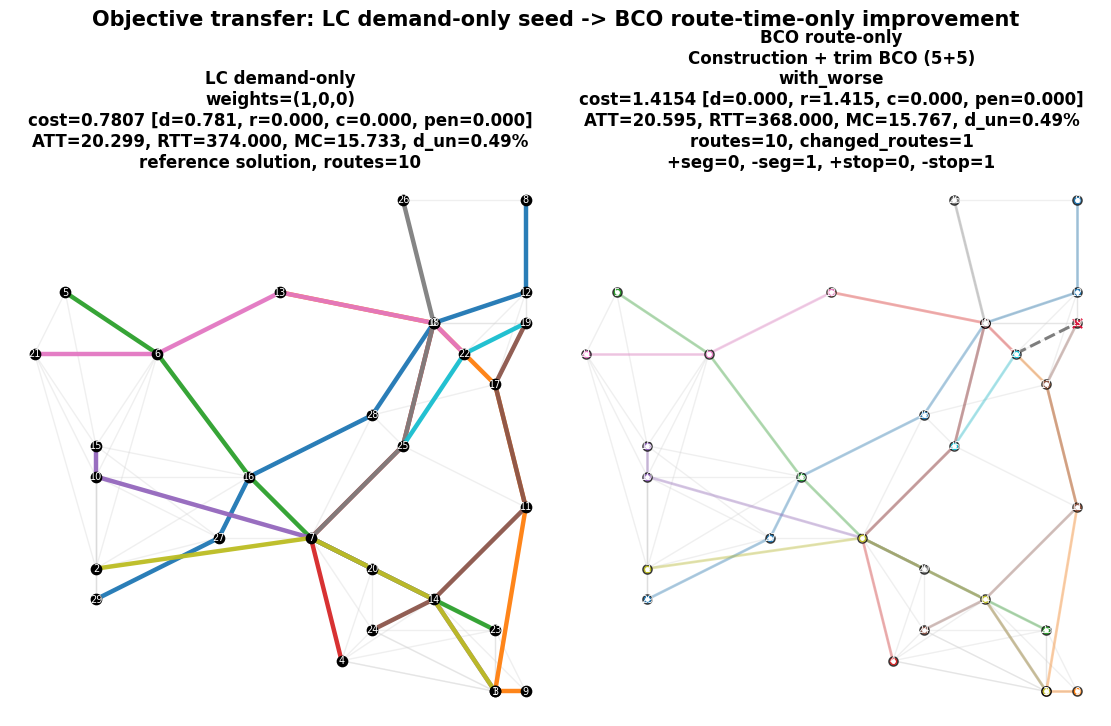

In [ ]:
OBJECTIVE_TRANSFER_LC_WEIGHTS = {
    "demand_time_weight": 1.0,
    "route_time_weight": 0.0,
    "median_connectivity_weight": 0.0,
}
OBJECTIVE_TRANSFER_BCO_WEIGHTS = {
    "demand_time_weight": 0.0,
    "route_time_weight": 1.0,
    "median_connectivity_weight": 0.0,
}
OBJECTIVE_TRANSFER_VARIANT_KEY = "construction_trim_split_5_5"
OBJECTIVE_TRANSFER_ACCEPT_KEY = "with_worse"
OBJECTIVE_TRANSFER_SEED = 0

objective_transfer_variant = next(
    variant for variant in BCO_VARIANTS if variant["key"] == OBJECTIVE_TRANSFER_VARIANT_KEY
)
objective_transfer_accept_cfg = next(
    cfg for cfg in WORSE_ACCEPT_EXPERIMENTS if cfg["key"] == OBJECTIVE_TRANSFER_ACCEPT_KEY
)

objective_transfer_lc_cfg = build_lc_cfg(
    run_name="objective_transfer_lc_demand_only_mumford0",
    n_routes=N_ROUTES,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
    **OBJECTIVE_TRANSFER_LC_WEIGHTS,
)
(
    objective_transfer_lc_run_name,
    objective_transfer_lc_metrics,
    objective_transfer_lc_unserved,
    objective_transfer_lc_routes,
    objective_transfer_lc_step_counts,
) = run_lc(objective_transfer_lc_cfg)

objective_transfer_bco_cfg = build_bco_cfg(
    run_name=route_selection_run_name(
        f"objective_transfer_{objective_transfer_variant['run_name']}_{OBJECTIVE_TRANSFER_ACCEPT_KEY}",
        "uniform",
    ),
    n_routes=N_ROUTES,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
    use_neural_bees=objective_transfer_variant["use_neural_bees"],
    n_type1_bees=objective_transfer_variant["n_type1_bees"],
    n_type2_bees=objective_transfer_variant["n_type2_bees"],
    n_type4_bees=objective_transfer_variant["n_type4_bees"],
    n_type5_bees=objective_transfer_variant.get("n_type5_bees", 0),
    n_type6_bees=objective_transfer_variant.get("n_type6_bees", 0),
    n_type7_bees=objective_transfer_variant.get("n_type7_bees", 0),
    ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
    ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
    ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
    ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
    use_demand_weighted_route_selection=False,
    worse_accept_temperature=objective_transfer_accept_cfg["temperature"],
    worse_accept_decay=objective_transfer_accept_cfg["decay"],
    worse_accept_min_temperature=objective_transfer_accept_cfg["min_temperature"],
    worse_selection_temperature=objective_transfer_accept_cfg["selection_temperature"],
    worse_selection_decay=objective_transfer_accept_cfg["selection_decay"],
    worse_selection_min_temperature=objective_transfer_accept_cfg["selection_min_temperature"],
    worse_selection_uniform_mix=objective_transfer_accept_cfg["selection_uniform_mix"],
    worse_selection_elite_count=objective_transfer_accept_cfg["selection_elite_count"],
    **OBJECTIVE_TRANSFER_BCO_WEIGHTS,
)
objective_transfer_bco_cfg.experiment.seed = OBJECTIVE_TRANSFER_SEED
objective_transfer_mutation_counts = {}
(
    objective_transfer_bco_run_name,
    objective_transfer_bco_metrics,
    objective_transfer_bco_unserved,
    objective_transfer_bco_routes,
    objective_transfer_mutation_counts,
) = run_bco(
    objective_transfer_bco_cfg,
    init_routes=objective_transfer_lc_routes,
    mutation_counts_out=objective_transfer_mutation_counts,
)

objective_transfer_rows = [
    {
        **summarize_run("LC demand-only weights (1,0,0)", objective_transfer_lc_metrics, objective_transfer_lc_routes),
        "weights": "LC: demand=1 route=0 conn=0",
    },
    {
        **summarize_run(
            f"BCO route-time-only weights (0,1,0): {objective_transfer_variant['summary_label']}",
            objective_transfer_bco_metrics,
            objective_transfer_bco_routes,
        ),
        "weights": "BCO: demand=0 route=1 conn=0",
    },
]
objective_transfer_df = pd.DataFrame(objective_transfer_rows)
display(objective_transfer_df.round(4))
print_bco_result(
    route_selection_mode_label("uniform"),
    objective_transfer_variant["summary_label"],
    objective_transfer_bco_run_name,
    objective_transfer_bco_metrics,
    objective_transfer_bco_routes,
    objective_transfer_mutation_counts,
)

coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
comparison_rows = [
    {
        "label": "LC demand-only\nweights=(1,0,0)",
        "routes": objective_transfer_lc_routes,
        "metrics": objective_transfer_lc_metrics,
        "is_reference": True,
    },
    {
        "label": f"BCO route-only\n{objective_transfer_variant['summary_label']}\n{OBJECTIVE_TRANSFER_ACCEPT_KEY}",
        "routes": objective_transfer_bco_routes,
        "metrics": objective_transfer_bco_metrics,
        "is_reference": False,
    },
]

fig, axes = plt.subplots(1, 2, figsize=(11, 8), squeeze=False, constrained_layout=True)
reference_row = comparison_rows[0]
for ax, row in zip(axes[0], comparison_rows):
    row_routes = get_first_route_set(row["routes"])
    n_nonempty_routes = int(((row_routes > -1).sum(dim=-1) > 1).sum().item())
    if row["is_reference"]:
        subtitle = f"{format_plot_metrics(row['metrics'])}\nreference solution, routes={n_nonempty_routes}"
        plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
        continue

    change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
    subtitle = (
        f"{format_plot_metrics(row['metrics'])}"
        f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
        f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
        f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
    )
    plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

fig.suptitle(
    "Objective transfer: LC demand-only seed -> BCO route-time-only improvement",
    fontsize=15,
    fontweight="bold",
)
plt.show()
